# Assignment 1: Graph Pathfinding with Genetic Algorithms


Firstly we will showcase all the code that we used in the tasks. We will start with the libraries we used.

In [2]:
import pandas as pd
import numpy as np
import pygad as pg
import networkx as nx
import random
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

We used the networkx library for creating directed graphs which we then saved to a txt file. Graphs are randomly created, with some probability to create a connection between random nodes. For the data analysis some graphs will be remodeled by hand, to make sure that the optimal path is a path with multiple nodes and to make more diverse graphs.

In [126]:
def create_graph(naloga=1, num_num=10, p=0.3, stAgentov=4):
    """
    Create directioned graph with:
     - naloga - The task number
     - num_num - Number of nodes
     - p - Probablity for two nodes to have a connection
    Return:
     - G - Created graph
    """
    G = nx.erdos_renyi_graph(n=num_num, p=p, directed=True)

    # Adding weights
    for u, v in G.edges():
        G[u][v]['weight'] = random.randint(1,10)

    if naloga == 1:
        with open("bla", "w") as file:
            file.write(f"{num_num} \n")
            uspesno = True
            num1 = random.randint(1, num_num)
            while uspesno:
                num2 = random.randint(1, num_num)
                if num1 != num2:
                    uspesno = False
                if num1 > num2:
                    num1, num2 = num2, num1
            file.write(f"{num1} {num2} \n")
            for u, v, w in G.edges(data='weight'):
                file.write(f"{u+1} {v+1} {w}\n")
    elif naloga == 2:
        with open("bla2", "w") as file:
            file.write(f"{num_num} \n")
            dolzina = random.randint(3, num_num)
            pot = []
            for i in range(dolzina):
                point = random.randint(1, num_num)
                pot.append(point)
            for i in range(dolzina-1):
                f = pot[i]
                s = pot[i+1]
                if f == s:
                    pot[i+1] = random.randint(1, num_num)
            for i in range(dolzina):
                file.write(f"{pot[i]} ")
            file.write(f"\n")
            for u, v, w in G.edges(data='weight'):
                file.write(f"{u+1} {v+1} {w}\n")
    elif naloga == 3:
        with open("3_10_02_4.txt", "w") as file:
            file.write(f"{num_num} \n")
            dolzina = random.randint(3, num_num)
            pot = []
            for i in range(dolzina):
                point = random.randint(1, num_num)
                pot.append(point)
            for i in range(dolzina-1):
                f = pot[i]
                s = pot[i+1]
                if f == s:
                    pot[i+1] = random.randint(1, num_num)
                agenti = []
            for i in range(stAgentov):
                while True:
                    nakljucno = random.randint(1, num_num)
                    if not nakljucno == pot[0]:
                        agenti.append(nakljucno)
                        break
            for i in range(stAgentov-1):
                f = agenti[i]
                s = agenti[i+1]
                if f == s:
                    agenti[i+1] = random.randint(1, num_num)
            for i in range(dolzina):
                file.write(f"{pot[i]} ")
            file.write(f"\n")
            for i in range(stAgentov):
                file.write(f"{agenti[i]} ")
            file.write(f"\n")
            for u, v, w in G.edges(data='weight'):
                file.write(f"{u+1} {v+1} {w}\n")
    return G

In [ ]:
G = create_graph(naloga = 3, num_num = 5, p = 0.2, stAgentov=2)

We used readData function to read the file we created, save the paramaters and save a graph in a helpfull way, as well as output an adjacency list and a connection matrix.

In [5]:
def readData(file):
    """
    Read input files for Task 1 and Task 2
    Returns:
    - N - Number of nodes
    - Route - The route to find
    - adj_list - Nodes and their neighbor nodes
    - adj_matrix - Matrix, where -1 means no connection, else presents connection's weight
    """
    N = -1
    Route = []
    Info = []

    # Read from file
    with open(file, 'r') as file:
        for line in file:
            if N == -1:
                N = int(line)
            elif not Route:
                line = line.rstrip()
                line = (line.split(' '))
                for i in range(len(line)):
                    Route.append(int(line[i]))
            else:
                line = line.rstrip()
                line = (line.split(' '))
                Info.append(line)

    adj_matrix = create_adjacency_matrix(Info, N)
    adj_list = create_adjacency_list(adj_matrix)


    return N, Route, adj_list, adj_matrix

In [6]:
def readData3(file):
    """
    Read input files for Task 3
    Returns:
    - N - Number of nodes
    - Route - The route to find
    - Agents - Agents positions
    - adj_list - Nodes and their neighbor nodes
    - adj_matrix - Matrix, where -1 means no connection, else presents connection's weight
    """
    N = -1
    Route = []
    Info = []
    Agents = []

    # Read from file
    with open(file, 'r') as file:
        for line in file:
            if N == -1:
                N = int(line)
            elif not Route:
                line = line.rstrip()
                line = (line.split(' '))
                for i in range(len(line)):
                    Route.append(int(line[i]))
            elif not Agents:
                line = line.rstrip()
                line = (line.split(' '))
                for i in range(len(line)):
                    Agents.append(int(line[i]))
            else:
                line = line.rstrip()
                line = (line.split(' '))
                Info.append(line)

    adj_matrix = create_adjacency_matrix(Info, N)
    adj_list = create_adjacency_list(adj_matrix)
    
    return N, Route, Agents, adj_list, adj_matrix


In [7]:
def create_adjacency_list(info):
    """
    Creates an adjacency list of graph in file
    """
    size = info.shape[0]
    adjacency_list = {}
    for i in range(size):
        adjacency_list[i] = []
        for j in range(size):
            if info.iat[i, j] != -1:
                adjacency_list[i].append(j)
    return adjacency_list

In [8]:
def create_adjacency_matrix(info, N):
    """
    Creates an adjacency matrix of graph in file
    """
    matrix = np.full((N,N),-1)
    for el in info:
        row = int(el[0])
        column = int(el[1])
        matrix[row-1,column-1] = int(el[2])

    adjacency_matrix = pd.DataFrame(matrix)
    return adjacency_matrix

plot_Graph plots the graph where we can see number of nodes, all of the connections and their weights.

In [9]:
def plot_Graph(adj_matrix, seed=42, title="Graf z utežmi"):
    np.random.seed(seed) 
    g = adj_matrix.to_numpy()
    g = np.where(g < 0, 0, g)

    G = nx.from_numpy_array(g, create_using=nx.DiGraph)
    G = nx.relabel_nodes(G, lambda x: x + 1)
    pos = nx.spring_layout(G, seed)
    
    nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=500)
    nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold')
    nx.draw_networkx_edges(G, pos, edge_color='gray', arrows=True, arrowsize=20)
    edge_labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='purple', font_size=8)

    plt.title(title)
    plt.show()

   0   1  2  3  4  5  6  7   8   9
0 -1   7 -1 -1  9 -1 -1 -1  -1   5
1 -1  -1 -1 -1 -1 -1 -1  1  -1  -1
2 -1   8 -1 -1 -1 -1 -1 -1  -1  -1
3 -1  10 -1 -1 -1 -1 -1  7   9  10
4 -1  -1 -1 -1 -1 -1 -1 -1  -1   9
5 -1  -1 -1 -1 -1 -1 -1 -1   4  -1
6 -1  -1 -1  3 -1 -1 -1  1   1  -1
7  4  -1 -1  3 -1  7 -1 -1  -1   4
8  7   5 -1  8  3 -1 -1  7  -1  -1
9 -1  -1 -1 -1  8  3 -1 -1  10  -1
<class 'pandas.core.frame.DataFrame'>
{0: [1, 4, 9], 1: [7], 2: [1], 3: [1, 7, 8, 9], 4: [9], 5: [8], 6: [3, 7, 8], 7: [0, 3, 5, 9], 8: [0, 1, 3, 4, 7], 9: [4, 5, 8]}


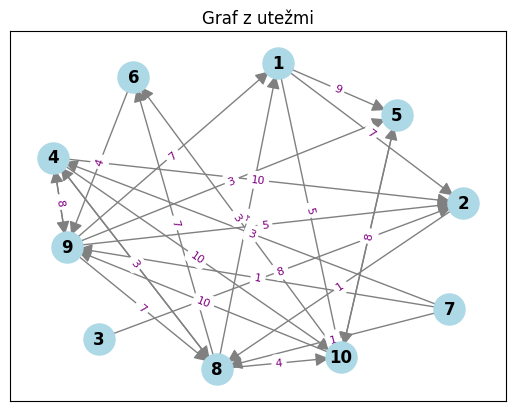

In [10]:
N, Route, adj_list, adj_matrix = readData('1_10_03.txt')
Start = Route[0]
Stop = Route[-1]

print(adj_matrix)
print(type(adj_matrix))
print(adj_list)

plot_Graph(adj_matrix)

# Task 1 - Shortest path between 2 nodes

We started with defining what our initial population should be. We know that the longest possible path in a graph between two nodes is the one were we visit all the nodes, so we defined our gene length as N where N is number of nodes in graph. We know were we should start and end out path so we locked in those two positions. In between we play with randomness. To make paths shorter than N possible we define that if a node -1 appears in the path our fitness function should ignore it. Taking the argument probability the function generates some -1 nodes in the path. Along with that to make the initial population better than just random we take the previous node in the path and choose a random node from its connection matrix. With this the genetic algorithm gets a head start at making the path.

In [11]:
def random_gene(length, probability=0.3):
    """
    Creates a random gene of the population
    """
    sol = [Start]
    current_node = Start - 1

    for _ in range(length):
        if np.random.rand() < probability:
            # Create -1 node
            sol.append(-1)
        else:
            if current_node in adj_list and len(adj_list[current_node]) > 0:
                # Create neighbor node
                next_node_0 = np.random.choice(adj_list[current_node])
                next_node = next_node_0 + 1 
                sol.append(next_node)
                current_node = next_node_0
            else:
                # Create -1 node
                sol.append(-1)

    sol.append(Stop)
    return sol

We created a custom Mutation function where we take one offspring, look only between first and last element (as the start and end will always stay the same) and we randomly choose between three possible scenarios.
- change: we change a random non -1 node into another one
- add: we change a random -1 node into a node random node on the graph
- remove: we change a random node into a -1 node.

In [12]:
def custom_mutation(offspring, ga_instance):
    num_nodes = adj_matrix.shape[0]

    for sol in offspring:
        # Create list of indices to choose from
        mutable_idx = np.arange(1, len(sol)-1)

        action = np.random.choice(["change", "add", "remove"], p=[0.8, 0.1, 0.1])

        if action == "change":
            # Change normal node to a random node
            filled = [i for i in mutable_idx if sol[i] != -1]
            if filled:
                pos = np.random.choice(filled)
                sol[pos] = np.random.randint(1, num_nodes+1)

        elif action == "add":
            # Convert -1 node to normal node
            empty = [i for i in mutable_idx if sol[i] == -1]
            if empty:
                pos = np.random.choice(empty)
                sol[pos] = np.random.randint(1, num_nodes+1)

        elif action == "remove":
            # Convert normal node to -1 node
            filled = [i for i in mutable_idx if sol[i] != -1]
            if filled:
                pos = np.random.choice(filled)
                sol[pos] = -1

    return offspring

We created a custom_crossover function, where we create an offspring from two consecutive parents. We only look between the first and
last element (as the start and end will always stay the same) and we randomly choose between three possible scenarios.

- we change i_element in child into i_element in parent 1
- we change i_element in child into i_element in parent 2
- we change i_element in child into random node from graph

In [13]:
def custom_crossover(parents, offspring_size, ga_instance):
    num_nodes = adj_matrix.shape[0] 

    parents = np.array(parents)
    num_offspring, chromosome_len = offspring_size
    
    offspring = np.empty((num_offspring, chromosome_len), dtype=int)
    mutable = np.arange(1, chromosome_len-1)

    for k in range(num_offspring):
        p1 = parents[k % parents.shape[0]]
        p2 = parents[(k + 1) % parents.shape[0]]

        child = p1.copy()

        for idx in mutable:
            r = np.random.rand()
            if r < 0.45:
                child[idx] = p1[idx]
            elif r < 0.9:
                child[idx] = p2[idx]
            else:
                child[idx] = np.random.randint(1, num_nodes + 1)

        child[0] = p1[0]
        child[-1] = p1[-1]

        offspring[k] = child

    return offspring

Our fitnes function firstly filters out -1 nodes. We then check the path in intervals of two consecutive elements. We check if they have a connection and if the connection exist we add its weight to result otherwise we increment invalid_edges which is counting how many invalid connection are in the solution. As we want our fitnes function to give better results to shorter paths we multiply the path length with -1. To avoid invalid edge connections we also subtract 20 * the number of invalid edges. If there are no invalid edges we reward the algorithm by adding 200 and also with adding the division of 1000 and result, as the number is bigger as result is smaller .

In [14]:
def fitnes1(pygad_instance, solution, solution_index):
    path = [node for node in solution if node != -1]
    result = 0
    invalid_edges = 0
    dol = len(path)

    for i in range(dol-1):
        first = path[i]
        second = path[i+1]

        distance = adj_matrix.iloc[first-1, second-1]

        if distance == -1:
            invalid_edges += 1
        else:
            result += distance

    fitness = -result
    fitness -= invalid_edges * 20

    if invalid_edges == 0:
        fitness += 200
        fitness += 1000/result

    return fitness

With the on_generation function we print out the generation number along with its best fitness, its path length, path cost and the population diversity. The function is called on every completed generation

In [15]:
def on_generation(ga_instance):
    """
    Callback function to track GA progress and diversity
    """
    generation = ga_instance.generations_completed
    solution, fitness, _ = ga_instance.best_solution()
    path = [int(node) for node in solution if node != -1]
    
    population_set = set()
    for sol in ga_instance.population:
        path_tuple = tuple([int(node) for node in sol if node != -1])
        population_set.add(path_tuple)
    
    diversity = len(population_set) / len(ga_instance.population)
    path_cost = sum(adj_matrix.iloc[path[i]-1, path[i+1]-1] for i in range(len(path)-1) if adj_matrix.iloc[path[i]-1, path[i+1]-1] != -1)
    
    print(f"Generation {generation}: Best fitness = {fitness:.2f}, "
            f"Path length: {len(path)} with cost {path_cost}, Population diversity: {diversity:.3f}")
            
    return True

The final function for task1 calls pygad.GA's genetic algorithm. The function arguments are used as variables in the GA. This is done to make testing the effect of changing a single or multiple parameters easier. We use built-in function from networkx libary, which returns shortest path in a graph.

In [67]:
def task1(file_name, population_size = 500, number_of_generations = 100, number_of_parents_mating = 200, mutation_probability = 0.4, crossover_probability = 0.4, saturate = 30, log_output = True, initial_pop = None):
    initial_population = np.array([random_gene(N, 0.3) for _ in range(population_size)])
    if not initial_pop is None:
        initial_population = initial_pop
    ga_instance = pg.GA(fitness_func=fitnes1,
                        num_generations=number_of_generations,
                        num_parents_mating=number_of_parents_mating,  
                        initial_population=initial_population,
                        init_range_low=1,
                        init_range_high=N+1,
                        gene_type=int,
                        mutation_type=custom_mutation,
                        mutation_probability=mutation_probability,  
                        crossover_type=custom_crossover,
                        crossover_probability=crossover_probability,
                        stop_criteria=f"saturate_{saturate}",  
                        on_generation= on_generation if log_output else None
                    )
    ga_instance.run()

    a, _, _ = ga_instance.best_solution()
    path = [int(node) for node in a if node != -1]

    #Creating graph and calculating shortest path
    g = adj_matrix.to_numpy()
    g = np.where(g < 0, 0, g)
    G = nx.from_numpy_array(g, create_using=nx.DiGraph)
    G = nx.relabel_nodes(G, lambda x: x + 1)
    c = nx.shortest_path(G, Start, Stop, 'weight')

    return path, ga_instance, c

Everytime we will call the task function we will also reset the global variables used in the various functions

In [17]:
N, Route, adj_list, adj_matrix = readData('1_30_01.txt')
Start = Route[0]
Stop = Route[-1]

#path, ga, c = task1('1_30_01.txt', log_output=True, number_of_parents_mating=300, population_size=500, crossover_probability=0.5, mutation_probability=0.3)
#print(ga.best_solution())
#print("Shortest path: ", c)
#print(Solutions)
#ga.plot_fitness()
#plot_Graph(adj_matrix)


## Task 2
Again we started with defining a custom initial population. A single gene is the same as in the first task but instead of making the path from the start to the end we define the first N, where N is the number of nodes, to be the path from the Start to the first node in the Route. Then we define the next N to be the path from the first node in the Route to the second one. We then repeat this untill we reach the end node. We are left with an array of length (M-1) * N, where M is the number of nodes in the Route, that is made of many segments of paths.

In [18]:
def random_gene2(length=N, probability=0.3, start = Start, stop = Stop):
    #Start and Stop are arguments
    
    sol = [start]
    current_node = start - 1  

    for _ in range(length-2):
        if np.random.rand() < probability:
            # Create -1 node
            sol.append(-1)
        else:
            if current_node in adj_list and len(adj_list[current_node]) > 0:
                # Create neighbor node
                next_node_0 = np.random.choice(adj_list[current_node])
                next_node = next_node_0 + 1  
                sol.append(next_node)
                current_node = next_node_0
            else:
                # Create -1 node
                sol.append(-1)

    sol.append(stop)
    return sol

Our custom mutation function for the second task is the same as in the first task but instead of just ignoring the first and last node it now ignores the start and end of each segment. By making all the segments the same size we know that the ends will be fixed to the indexes 0, N-1, N, 2N-1, 2N, 3N-1, ..., (M-2)N,(M-1)N, where N is the number of nodes and M is the number of nodes in the Route 

In [19]:
def custom_mutation2(offspring, ga_instance):
    num_nodes = adj_matrix.shape[0]
    num_path = len(Route)

    for sol in offspring:

        # Create set of indices to ignore
        ignore_indices = set()
        for segment_idx in range(num_path-1):
            first_idx = segment_idx * num_nodes 
            last_idx = (segment_idx + 1) * num_nodes - 1  
            ignore_indices.add(first_idx)
            ignore_indices.add(last_idx)

        # Create a list of indices we can use for mutation
        mutable_idx = [i for i in range(len(sol)) if i not in ignore_indices]
        if len(mutable_idx) == 0:
            continue

        action = np.random.choice(["change", "add", "remove"], p=[0.8, 0.1, 0.1])

        if action == "change":
            filled = [i for i in mutable_idx if sol[i] != -1]
            if filled:
                pos = np.random.choice(filled)
                sol[pos] = np.random.randint(1, num_nodes+1)

        elif action == "add":
            empty = [i for i in mutable_idx if sol[i] == -1]
            if empty:
                pos = np.random.choice(empty)
                sol[pos] = np.random.randint(1, num_nodes+1)

        elif action == "remove":
            filled = [i for i in mutable_idx if sol[i] != -1]
            if filled:
                pos = np.random.choice(filled)
                sol[pos] = -1

    return offspring

Our custom crossover function for the second task is the same as in the first task but instead of just ignoring the first and last node it now ignores the start and end of each segment.

In [20]:
def custom_crossover2(parents, offspring_size, ga_instance):
    num_nodes = adj_matrix.shape[0]
    num_path = len(Route)

    parents = np.array(parents)
    num_offspring, chromosome_len = offspring_size
    offspring = np.empty((num_offspring, chromosome_len), dtype=int)

    ignore_indices = set()
    for segment_idx in range(num_path-1):
        first_idx = segment_idx * num_nodes
        last_idx = (segment_idx + 1) * num_nodes - 1
        ignore_indices.add(first_idx)
        ignore_indices.add(last_idx)

    mutable_idx = [i for i in range(chromosome_len) if i not in ignore_indices]

    for k in range(num_offspring):
        # We choose two consecutive parents
        p1 = parents[k % parents.shape[0]]
        p2 = parents[(k + 1) % parents.shape[0]]

        child = p1.copy()

        # For mutable indices we either add a node from the first or second parent or a random node
        for idx in mutable_idx:
            r = np.random.rand()
            if r < 0.45:
                child[idx] = p1[idx]
            elif r < 0.9:
                child[idx] = p2[idx]
            else:
                child[idx] = np.random.randint(1, num_nodes+1)

        # Boundary nodes stay the same
        for idx in ignore_indices:
            child[idx] = p1[idx]

        offspring[k] = child

    return offspring

For our fitnes function in this task we repeat the behaviour we made in the first task but instead of going through the whole solution in one pass we go through each segment in the path and then combine the results.

In [21]:
def fitnes2(pygad_instance, solution, solution_index):
    num_nodes = adj_matrix.shape[0]
    num_path = len(Route)

    edge_penalty = 50
    result = 0
    invalid_edges = 0
    
    # Process each segment
    for segment_idx in range(num_path - 1):
        start_pos = segment_idx * num_nodes
        end_pos = start_pos + num_nodes
        segment = solution[start_pos:end_pos]

        # Get path without -1 nodes
        path_nodes = [node for node in segment if node != -1]

        for i in range(len(path_nodes) - 1):
            first = path_nodes[i] - 1 
            second = path_nodes[i + 1] - 1

            distance = adj_matrix.iloc[first, second]
            if distance == -1:
                invalid_edges += 1
            else:
                result += distance

    # Convert distance to fitnes
    fitness = -result
    fitness -= invalid_edges * edge_penalty

    if invalid_edges == 0:
        fitness += 500
        fitness += 1000/result

    return fitness

In the final function of task two we repeat the behavior from task one.

In [105]:
def task2(file_name, population_size = 500, number_of_generations = 100, number_of_parents_mating = 200, mutation_probability = 0.4, crossover_probability = 0.4, saturate = 30, log_output = True,  initial_pop=None):
    num_nodes = adj_matrix.shape[0]
    num_path = len(Route)

    initial_population = [] #creating starting population the size of population_size
    for i in range(population_size):
        gene = []
        for j in range(num_path-1):
            start, stop = Route[j], Route[j+1]
            gene.extend(random_gene2(num_nodes, 0.3,start,stop))
        initial_population.append(gene)

    if not initial_pop is None:
        initial_population = initial_pop
    
    ga_instance = pg.GA(fitness_func=fitnes2,
                        num_generations=number_of_generations,
                        num_parents_mating=number_of_parents_mating,  
                        initial_population=initial_population,
                        init_range_low=1,
                        init_range_high=num_nodes+1,
                        gene_type=int,
                        mutation_type=custom_mutation2,
                        mutation_probability=mutation_probability,  
                        crossover_type=custom_crossover2,
                        crossover_probability=crossover_probability,
                        stop_criteria=f"saturate_{saturate}",  
                        on_generation=on_generation if log_output else None 
                    )
    ga_instance.run()
    a, _, _ = ga_instance.best_solution()
    
    path = []
    cur_path=[]
    prejsna = None
    for i in range(len(a)):
        if a[i] != -1:
            if a[i] == prejsna:
                path.append(cur_path)
                cur_path = []

            cur_path.append(int(a[i]))
            prejsna = a[i]

    if cur_path:
        path.append(cur_path)

    #Creating graph and calculating shortest path
    g = adj_matrix.to_numpy()
    g = np.where(g < 0, 0, g)
    G = nx.from_numpy_array(g, create_using=nx.DiGraph)
    G = nx.relabel_nodes(G, lambda x: x + 1)
    c = []
    for i in range(len(Route)-1):
        c.append(nx.shortest_path(G, Route[i], Route[i+1], 'weight'))


    return path, ga_instance, c

In [23]:
N, Route, adj_list, adj_matrix = readData('2_20_01.txt')
Start = Route[0]
Stop = Route[-1]

#path, ga, c = task2('2_20_01.txt', log_output=True, number_of_parents_mating=200, population_size=500)
#print(ga.best_solution())
#print(path)
#ga.plot_fitness()
#plot_Graph(adj_matrix)
#print(c)

## Task 3

We again started with defining our initial population genes. To include all agents in the gene we use the gene definition from task 2 and make that the definition for each agent. Doing so we know the length of each agents genes and we can again just create a list of nodes where the first (M-1)*N nodes are for the first agent, the second are for the second and so on. To account for the agents capability to wait we define that if a node is -2 that means the agent is going to wait on the node for 20 time units. When creating a path -2 nodes are created the same way as -1 nodes.

In [24]:
def random_gene3(length, start, stop, probability=0.3):
    sol = [start]
    current_node = start - 1  

    for _ in range(length-2):
        random = np.random.rand()
        if random < probability / 2:
            # Create -1 node
            sol.append(-1)
        elif random < probability:
            # Create -2 node
            sol.append(-2)
        else:
            if current_node in adj_list and len(adj_list[current_node]) > 0:
                # Create neighbor node
                next_node_0idx = np.random.choice(adj_list[current_node])
                next_node = next_node_0idx + 1  
                sol.append(next_node)
                current_node = next_node_0idx
            else:
                # Create -1 node
                sol.append(-1)

    sol.append(stop)
    return sol

In the mutation function we again create a list of indices we want to ignore. Our job here is simple as we already implemented this in task 2 so we create a list of indicies for the first agent using that. Then we go through the list and add an offset of (M-1)*N for each agent. When changing a node we also change it into a -2 node with a chance of 10%.

In [25]:
def custom_mutation3(offspring, ga_instance):
    num_nodes = adj_matrix.shape[0]
    num_path = len(Route)
    num_agents = len(Agents)

    for sol in offspring:

        # Create ignore list for a single agent
        ignore_indices = set()
        for segment_idx in range(num_path):
            first_idx = segment_idx * num_nodes
            last_idx = (segment_idx + 1) * num_nodes - 1
            ignore_indices.add(first_idx)
            ignore_indices.add(last_idx)

        # Create ignore list for all agents
        ignoring = ignore_indices.copy()
        for agent_idx in range(num_agents):
            offset = (num_path-1) * num_nodes * (agent_idx + 1)
            for key in ignoring:
                moved_key = key + offset
                ignore_indices.add(moved_key)

        # Create a list of usable indices
        mutable_idx = [i for i in range(len(sol)) if i not in ignore_indices]
        if len(mutable_idx) == 0:
            continue


        action = np.random.choice(["change", "add", "remove"],
                                p=[0.8, 0.1, 0.1])

        if action == "change":
            filled = [i for i in mutable_idx if sol[i] != -1]
            if filled:
                # Create a -2 node with a chance of 10%
                pos = np.random.choice(filled)
                if np.random.rand() < 0.1:
                    sol[pos] = -2
                else:
                    sol[pos] = np.random.randint(1,num_nodes+1)

        elif action == "add":
            empty = [i for i in mutable_idx if sol[i] == -1]
            if empty:
                pos = np.random.choice(empty)
                sol[pos] = np.random.randint(1, num_nodes+1)

        elif action == "remove":
            filled = [i for i in mutable_idx if sol[i] != -1]
            if filled:
                pos = np.random.choice(filled)
                sol[pos] = -1

    return offspring

The custom crossover function is the same as in task one and two, we just have to be careful with boundries for agents, and we added possibility that element becomes -2.

In [26]:
def custom_crossover3(parents, offspring_size, ga_instance):
    num_nodes = adj_matrix.shape[0]
    num_path = len(Route)
    num_agents = len(Agents)
    
    parents = np.array(parents)
    num_offspring, chromosome_len = offspring_size
    offspring = np.empty((num_offspring, chromosome_len), dtype=int)

    for k in range(num_offspring):
        # We choose parents
        p1 = parents[k % parents.shape[0]]
        p2 = parents[(k + 1) % parents.shape[0]]

        child = p1.copy()

        # Create set of indices to ignore
        ignore_indices = set()
        for segment_idx in range(num_path):
            first_idx = segment_idx * num_nodes
            last_idx = (segment_idx + 1) * num_nodes-1
            ignore_indices.add(first_idx)
            ignore_indices.add(last_idx)

        # Boundry points for agents
        for agent_idx in range(num_agents):
            for key in list(ignore_indices):
                moved_key = key + (num_path) * num_nodes * agent_idx
                ignore_indices.add(moved_key)

        # Indices we can change
        mutable_idx = [i for i in range(chromosome_len) if i not in ignore_indices]

        for idx in mutable_idx:
            r = np.random.rand()
            if r < 0.45:
                child[idx] = p1[idx]
            elif r < 0.9:
                child[idx] = p2[idx]
            else:
                # Either waiting or random node
                r2 = np.random.rand()
                if r2 < 0.3:
                    child[idx] = -2  # waiting
                else:
                    child[idx] = np.random.randint(1, num_nodes+1)

        # Boundry points should stay the same
        for idx in ignore_indices:
            if idx < chromosome_len:
                child[idx] = p1[idx]

        offspring[k] = child

    return offspring

For task 3's fitnes function we go through the solution and process one agent at a time. For each agent we compute at which intervals of time they were occupying a node. When we process all agents we get a dictionary of nodes and the intervals of agents' occupations. We then go through each node and check how many intervals are wrong. Then we multiply this number with a penalty of 100 and add it to the final fitnes. The distance of the paths is computed the same way as in task 2 and is then also added to the fitnes score. We also assume that the base wait time after each move is 10 time units.

In [27]:
def fitnes3(pygad_instance, solution, solution_index):
    """
    For each agent calculate path distance and the time intervals of node occupation
    After that calculate total fitnes
    """
    num_nodes = adj_matrix.shape[0]
    num_path = len(Route)
    num_agents = len(Agents)

    edge_penalty = 50
    interval_penalty = 100
    result = 0
    invalid_edges = 0
    intervals = {}

    # Process each agent
    for agent_idx in range(num_agents + 1):
        offset = (num_path-1) * num_nodes * agent_idx
        # Process each segment of agent
        time = 0
        last = 0
        if agent_idx == num_agents:
            last = 1
        for segment_idx in range(num_path - 1 + last):
            start_pos = segment_idx * num_nodes + offset
            end_pos = start_pos + num_nodes
            segment = solution[start_pos:end_pos]

            path_nodes = [node for node in segment if node != -1]

            previous_node = -2
            wait_count = 0

            # Calculate distances for consecutive nodes
            for i in range(len(path_nodes) - 1):
                first = path_nodes[i] - 1  # Convert to 0-indexed
                second = path_nodes[i + 1] - 1

                if first != -3 and second != -3:
                    # First and second arent wait
                    distance = adj_matrix.iloc[first, second]
                    if distance == -1:
                        invalid_edges += 1
                    else:
                        # Base wait is 10 time units
                        if not intervals.get(first):
                            intervals[first] = []
                        intervals[first].append((int(time), int(time + 10)))
                        time += 10 + distance
                        result += distance

                elif first != -3 and second == -3:
                    # First is node, Second is wait so start counting chain
                    previous_node = first
                    wait_count += 1

                elif first == -3 and second == -3:
                    # First and Second are wait so count up
                    wait_count += 1

                else:
                    # First is wait, Second is node stop chain and calculate interval
                    distance = adj_matrix.iloc[previous_node, second]
                    if distance == -1:
                        invalid_edges += 1
                    else:
                        # Base wait is 10 time units + 20 per wait in chain
                        if not intervals.get(previous_node):
                            intervals[previous_node] = []
                        intervals[previous_node].append((int(time), int(time + 10 + 20 * wait_count)))
                        time += 10 + 20 * wait_count + distance
                        result += distance
                    previous_node = -2
                    wait_count = 0

    # Count invalid intervals
    invalid_intervals = 0
    for node, node_intervals in intervals.items():
        events = []
        for start, end in node_intervals:
            events.append((start, 1))   # interval starts
            events.append((end, -1))    # interval ends
        events.sort()

        active = 0
        for time, event_type in events:
            if event_type == 1:
                # new interval starts
                if active > 0:
                    invalid_intervals += 1
                active += 1
            else:
                active -= 1


    fitness = -result
    fitness -= invalid_edges * edge_penalty
    fitness -= invalid_intervals * interval_penalty

    if invalid_edges == 0 and invalid_intervals == 0:
        fitness += 500
        fitness += 1000/result
    elif invalid_intervals == 0:
        fitness += 300
    elif invalid_edges == 0:
        fitness += 150

    return fitness

The final function is also the same as before wtih a changed initial population to account for more agents

In [150]:
def task3(file_name, population_size = 500, number_of_generations = 100, number_of_parents_mating = 200, mutation_probability = 0.4, crossover_probability = 0.4, saturate = 30, log_output = True, initial_pop = None):
    num_nodes = adj_matrix.shape[0]
    num_path = len(Route)
    num_agents = len(Agents)

    pop_size = 1000
    initial_population = []
    for i in range(pop_size):
        gene = []
        for k in Agents:
            agent = []
            agent.extend(random_gene3(num_nodes, 0.3,k,Route[0]))
            for j in range(num_path - 1):
                start, stop = Route[j], Route[j+1]
                agent.extend(random_gene3(num_nodes, 0.3,start,stop))
            gene.extend(agent)
        initial_population.append(gene)

    if not initial_pop is None:
        initial_population = initial_pop
    
    ga_instance = pg.GA(fitness_func=fitnes3,
                        num_generations=number_of_generations,
                        num_parents_mating=number_of_parents_mating,  
                        initial_population=initial_population,
                        init_range_low=1,
                        init_range_high=num_nodes+1,
                        gene_type=int,
                        mutation_type=custom_mutation3,
                        mutation_probability=mutation_probability,  
                        crossover_type=custom_crossover3,
                        crossover_probability=crossover_probability,
                        stop_criteria=f"saturate_{saturate}",  
                        on_generation=on_generation if log_output else None 
                    )
    ga_instance.run()
    a, _, _ = ga_instance.best_solution()
    
    sol = []
    agent = []
    for i in range(len(a)):
        agent.append(a[i])
        if (i + 1) % (num_path * num_nodes) == 0:
            sol.append(np.array(agent))
            agent = []

    #Creating graph and calculating the shortest path
    g = adj_matrix.to_numpy()
    g = np.where(g < 0, 0, g)
    G = nx.from_numpy_array(g, create_using=nx.DiGraph)
    G = nx.relabel_nodes(G, lambda x: x + 1)
    c = []

    for i in range(len(Agents)):
        first = Agents[i]
        a = []
        a.append(nx.shortest_path(G, first, Route[0], 'weight'))
        for j in range(len(Route)-1):
            a.append(nx.shortest_path(G, Route[j], Route[j+1], 'weight'))
        c.append(a)

    return sol, ga_instance, c

In [138]:
N, Route, Agents, adj_list, adj_matrix = readData3('3_5_02_2.txt')
Start = Route[0]
Stop = Route[-1]

#sol, ga, c = task3('3_15_03_4.txt', log_output=True, number_of_parents_mating=200, population_size=500)
#print(ga.best_solution())
#for s in sol:
#   print(s)
#ga.plot_fitness()
#plot_Graph(adj_matrix)
#print(c)

## Task 4 - Analisys

Firstly we made function to draw a graph with the correct path and our soulution.

In [ ]:
def how_correct(path, c, seed=42, adj_matrix=adj_matrix):
    np.random.seed(seed)
    g = adj_matrix.to_numpy()
    g = np.where(g < 0, 0, g)

    G = nx.from_numpy_array(g, create_using=nx.DiGraph)
    G = nx.relabel_nodes(G, lambda x: x + 1)

    pos = nx.spring_layout(G, seed=seed)
    nx.draw(G, pos,
        with_labels=True,
        node_color="lightgray",
        edge_color="lightgray",
        node_size=600,
        width=2)

    path_edges = list(zip(path, path[1:]))
    correct_edges = list(zip(c, c[1:]))

    nx.draw_networkx_nodes(G, pos,
                       nodelist=path,
                       node_color="blue")

    nx.draw_networkx_edges(G, pos,
                       edgelist=path_edges,
                       edge_color="blue",
                       width=3)

    nx.draw_networkx_nodes(G, pos,
                       nodelist=c,
                       node_color="red")

    nx.draw_networkx_edges(G, pos,
                       edgelist=correct_edges,
                       edge_color="red",
                       width=3)

    plt.show()

In [ ]:
def how_correct2(path, c, seed=42, adj_matrix=adj_matrix):
    np.random.seed(seed)
    g = adj_matrix.to_numpy()
    g = np.where(g < 0, 0, g)

    G = nx.from_numpy_array(g, create_using=nx.DiGraph)
    G = nx.relabel_nodes(G, lambda x: x + 1)

    pos = nx.spring_layout(G, seed=seed)
    nx.draw(G, pos,
            with_labels=True,
            node_color="lightgray",
            edge_color="lightgray",
            node_size=600,
            width=2)


    listtt = []
    for a in path:
        listtt.extend(a)

    listt = []
    for a in c:
        listt.extend(a)

    path_edges = list(zip(listtt, listtt[1:]))
    correct_edges = list(zip(listt, listt[1:]))

    nx.draw_networkx_nodes(G, pos,
                           nodelist=listtt,
                           node_color="blue")

    nx.draw_networkx_edges(G, pos,
                           edgelist=path_edges,
                           edge_color="blue",
                           width=3)

    nx.draw_networkx_nodes(G, pos,
                           nodelist=listt,
                           node_color="red")

    nx.draw_networkx_edges(G, pos,
                           edgelist=correct_edges,
                           edge_color="red",
                           width=3)

    plt.show()


### Task 1

First we will test our implementation of the first task on different graph sizes with a differing amount of connections

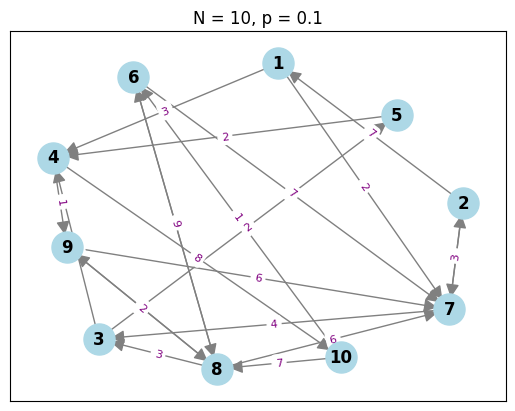

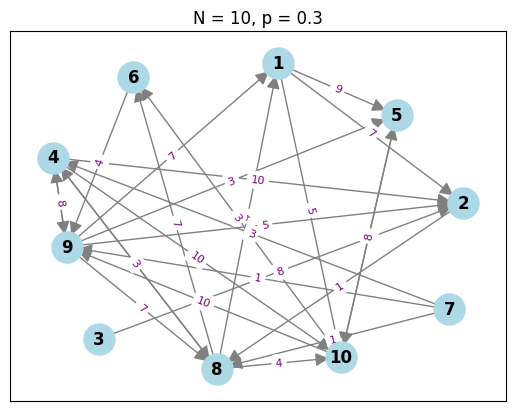

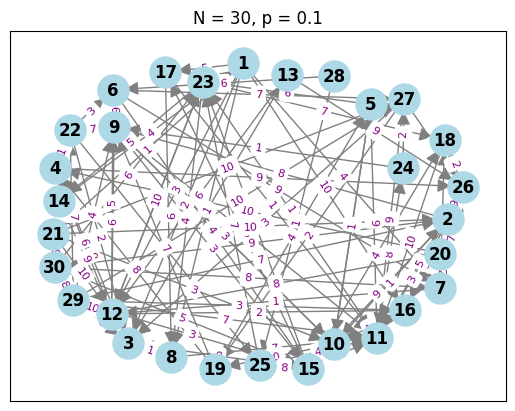

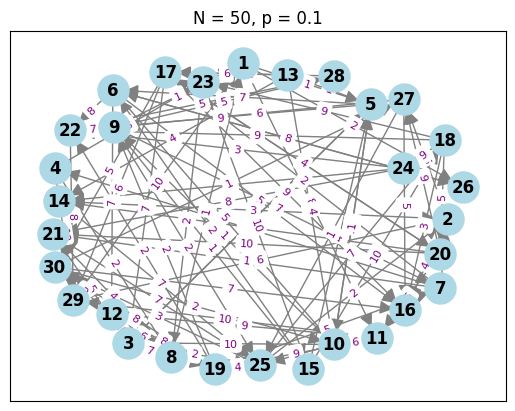

In [30]:
N, Route, adj_list, adj_matrix1 = readData('1_10_01.txt')
N, Route, adj_list, adj_matrix2 = readData('1_10_03.txt')
N, Route, adj_list, adj_matrix3 = readData('1_30_01.txt')
N, Route, adj_list, adj_matrix4 = readData('1_50_01.txt')

plot_Graph(adj_matrix1, title="N = 10, p = 0.1")
plot_Graph(adj_matrix2, title="N = 10, p = 0.3")
plot_Graph(adj_matrix3, title="N = 30, p = 0.1")
plot_Graph(adj_matrix4, title="N = 50, p = 0.1")

Running our implementation on the graphs we can see that for the smallest one the solution is found almost instantly while for the larger ones our program starts to struggle a bit. Going forward, if not explicitly mentioned, we will use the parameters:

    population_size: 500,
    number_of_generations: 100,
    number_of_parents_mating: 200,
    mutation_probability: 0.4,
    crossover_probability: 0.4,
    saturate: 30

In [47]:
N, Route, adj_list, adj_matrix1 = readData('1_10_01.txt')
Start = Route[0]
Stop = Route[-1]
adj_matrix = adj_matrix1
path1, ga1, c1 = task1('1_10_01.txt', log_output=False)

N, Route, adj_list, adj_matrix2 = readData('1_10_03.txt')
Start = Route[0]
Stop = Route[-1]
adj_matrix = adj_matrix2
path2, ga2, c2 = task1('1_10_03.txt', log_output=False)

N, Route, adj_list, adj_matrix3 = readData('1_30_01.txt')
Start = Route[0]
Stop = Route[-1]
adj_matrix = adj_matrix3
path3, ga3, c3 = task1('1_30_01.txt', log_output=False)

N, Route, adj_list, adj_matrix4 = readData('1_50_01.txt')
Start = Route[0]
Stop = Route[-1]
adj_matrix = adj_matrix4
path4, ga4, c4 = task1('1_50_01.txt', log_output=False)

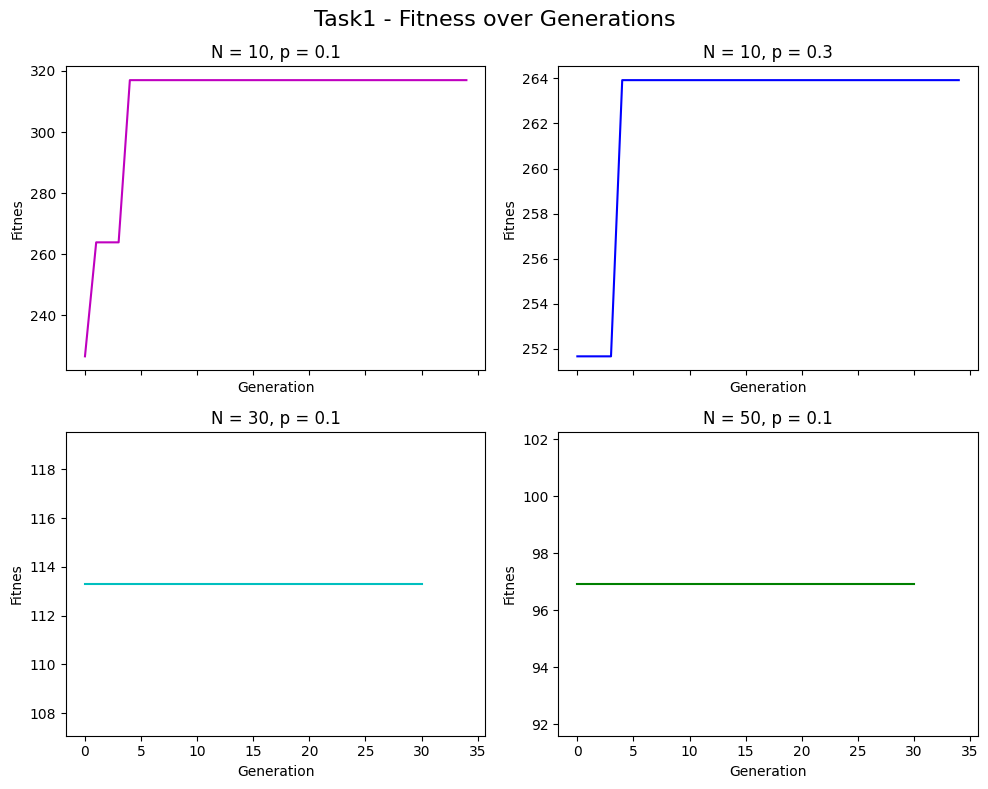

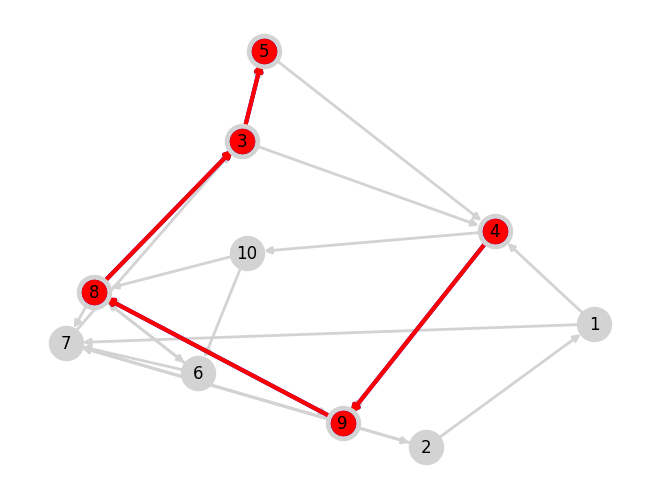

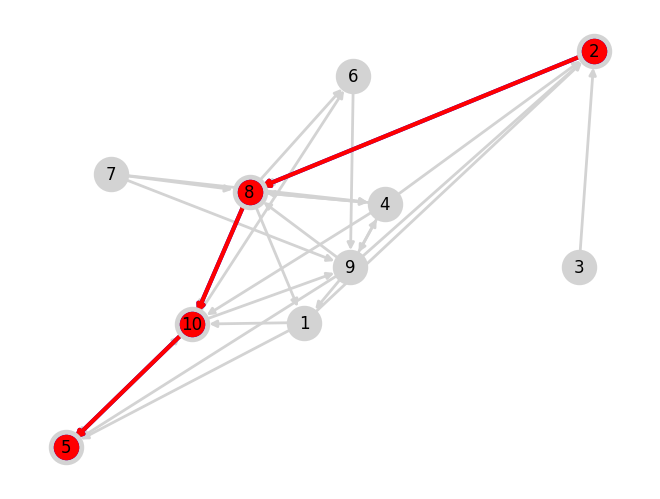

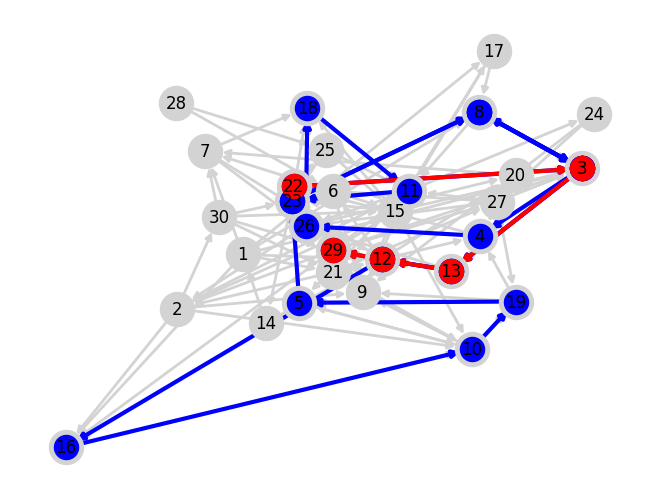

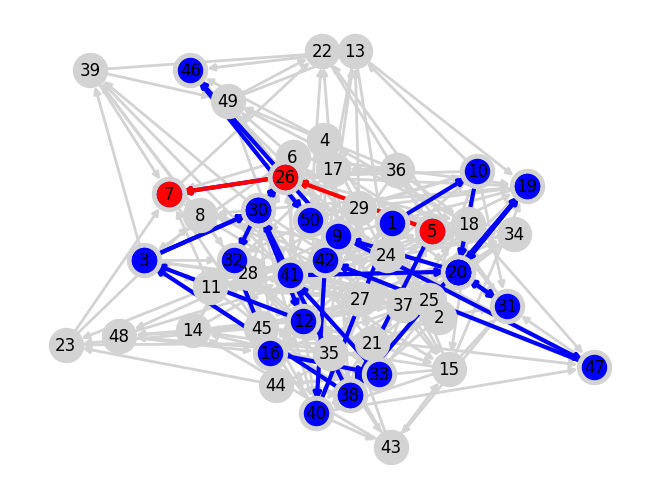

In [48]:
fig, ax = plt.subplots(2, 2, figsize=(10, 8), sharex=True)
fig.suptitle("Task1 - Fitness over Generations", fontsize=16)

ax[0][0].plot(ga1.best_solutions_fitness, color="m")
ax[0][0].set_title("N = 10, p = 0.1")
ax[0][0].set_ylabel("Fitnes")
ax[0][0].set_xlabel("Generation")

ax[0][1].plot(ga2.best_solutions_fitness, color="b")
ax[0][1].set_title("N = 10, p = 0.3")
ax[0][1].set_ylabel("Fitnes")
ax[0][1].set_xlabel("Generation")

ax[1][0].plot(ga3.best_solutions_fitness, color="c")
ax[1][0].set_title("N = 30, p = 0.1")
ax[1][0].set_ylabel("Fitnes")
ax[1][0].set_xlabel("Generation")

ax[1][1].plot(ga4.best_solutions_fitness, color="g")
ax[1][1].set_title("N = 50, p = 0.1")
ax[1][1].set_ylabel("Fitnes")
ax[1][1].set_xlabel("Generation")


plt.tight_layout()
plt.show()

how_correct(path1, c1, 42, adj_matrix1)
how_correct(path2, c2, 42, adj_matrix2)
how_correct(path3, c3, 42, adj_matrix3)
how_correct(path4, c4, 42, adj_matrix4)


As we can see our genetic algorithm works the best on smaller sized graphs, while on the bigger ones the soultion is stuck on the initially generated path. We can also observe that on the first two graphs the fitnes value quickly converged to the best possible solution. Due to our testing and computation limitations we decided to use the second graph (with N = 10 and p = 0.3) in our following analysis.

Next we will check how our implementation changes with changing input variables. First lets check how the parameters population_size and number_of_parents_mating influence the result. We will be testing two different configurations with differing sizes. One where the number of parents mating is 10% of the total population and one where its 50% of the population.

In [107]:
N, Route, adj_list, adj_matrix = readData('1_10_03.txt')
Start = Route[0]
Stop = Route[-1]

path1, ga1, _ = task1('1_10_03.txt', log_output=False, population_size=100, number_of_parents_mating=10)
path2, ga2, _ = task1('1_10_03.txt', log_output=False, population_size=200, number_of_parents_mating=20)
path3, ga3, _ = task1('1_10_03.txt', log_output=False, population_size=400, number_of_parents_mating=40)
path4, ga4, _ = task1('1_10_03.txt', log_output=False, population_size=800, number_of_parents_mating=80)
path5, ga5, _ = task1('1_10_03.txt', log_output=False, population_size=100, number_of_parents_mating=50)
path6, ga6, _ = task1('1_10_03.txt', log_output=False, population_size=200, number_of_parents_mating=100)
path7, ga7, _ = task1('1_10_03.txt', log_output=False, population_size=400, number_of_parents_mating=200)
path8, ga8, _ = task1('1_10_03.txt', log_output=False, population_size=800, number_of_parents_mating=400)

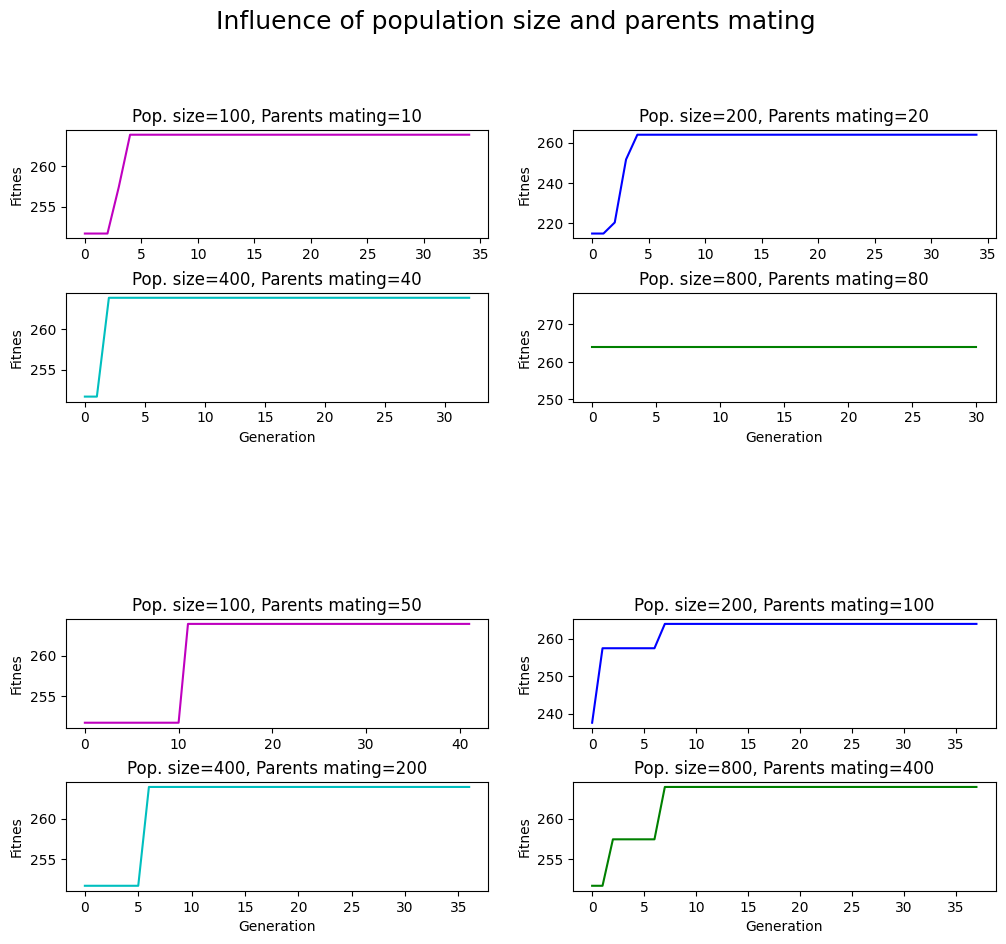

In [108]:
fig = plt.figure(figsize=(12, 12))
fig.suptitle("Influence of population size and parents mating", fontsize=18)

gs = gridspec.GridSpec(6, 2, figure=fig)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

ax5 = fig.add_subplot(gs[3, 0])
ax6 = fig.add_subplot(gs[3, 1])
ax7 = fig.add_subplot(gs[4, 0])
ax8 = fig.add_subplot(gs[4, 1])

plt.subplots_adjust(hspace=0.5)

ax1.plot(ga1.best_solutions_fitness, color="m")
ax1.set_title("Pop. size=100, Parents mating=10")
ax1.set_ylabel("Fitnes")

ax2.plot(ga2.best_solutions_fitness, color="b")
ax2.set_title("Pop. size=200, Parents mating=20")
ax2.set_ylabel("Fitnes")

ax3.plot(ga3.best_solutions_fitness, color="c")
ax3.set_title("Pop. size=400, Parents mating=40")
ax3.set_ylabel("Fitnes")
ax3.set_xlabel("Generation")

ax4.plot(ga4.best_solutions_fitness, color="g")
ax4.set_title("Pop. size=800, Parents mating=80")
ax4.set_ylabel("Fitnes")
ax4.set_xlabel("Generation")


ax5.plot(ga5.best_solutions_fitness, color="m")
ax5.set_title("Pop. size=100, Parents mating=50")
ax5.set_ylabel("Fitnes")

ax6.plot(ga6.best_solutions_fitness, color="b")
ax6.set_title("Pop. size=200, Parents mating=100")
ax6.set_ylabel("Fitnes")

ax7.plot(ga7.best_solutions_fitness, color="c")
ax7.set_title("Pop. size=400, Parents mating=200")
ax7.set_ylabel("Fitnes")
ax7.set_xlabel("Generation")

ax8.plot(ga8.best_solutions_fitness, color="g")
ax8.set_title("Pop. size=800, Parents mating=400")
ax8.set_ylabel("Fitnes")
ax8.set_xlabel("Generation")

plt.show()

We can observe that the algorithm improves faster when the number of parents mating is 10% of the total population.

Next we will test the effectivness of our implementation when changing the probability of mutation and crossover. We will be testing both probabilities on a range of 0-1 while incrementing by 0.1. We also run all the ga's on the same initial population to see their improvement on it.

In [78]:
N, Route, adj_list, adj_matrix = readData('1_10_03.txt')
Start = Route[0]
Stop = Route[-1]

initial_pop = np.array([random_gene(N, 0.3) for _ in range(500)])

path1, ga1, c1 = task1('1_10_03.txt', log_output=False, mutation_probability=1, crossover_probability=0, initial_pop=initial_pop)
path2, ga2, c2 = task1('1_10_03.txt', log_output=False, mutation_probability=0.9, crossover_probability=0.1, initial_pop=initial_pop)
path3, ga3, c3 = task1('1_10_03.txt', log_output=False, mutation_probability=0.8, crossover_probability=0.2, initial_pop=initial_pop)
path4, ga4, c4 = task1('1_10_03.txt', log_output=False, mutation_probability=0.7, crossover_probability=0.3, initial_pop=initial_pop)
path5, ga5, c5 = task1('1_10_03.txt', log_output=False, mutation_probability=0.6, crossover_probability=0.4, initial_pop=initial_pop)
path6, ga6, c6 = task1('1_10_03.txt', log_output=False, mutation_probability=0.5, crossover_probability=0.5, initial_pop=initial_pop)
path7, ga7, c7 = task1('1_10_03.txt', log_output=False, mutation_probability=0.4, crossover_probability=0.6, initial_pop=initial_pop)
path8, ga8, c8 = task1('1_10_03.txt', log_output=False, mutation_probability=0.3, crossover_probability=0.7, initial_pop=initial_pop)
path9, ga9, c9 = task1('1_10_03.txt', log_output=False, mutation_probability=0.2, crossover_probability=0.8, initial_pop=initial_pop)
path10, ga10, c10 = task1('1_10_03.txt', log_output=False, mutation_probability=0.1, crossover_probability=0.9, initial_pop=initial_pop)
path11, ga11, c11 = task1('1_10_03.txt', log_output=False, mutation_probability=0, crossover_probability=1, initial_pop=initial_pop)
gas = [ga1,ga2,ga3,ga4,ga5,ga6,ga7,ga8,ga9,ga10,ga11]

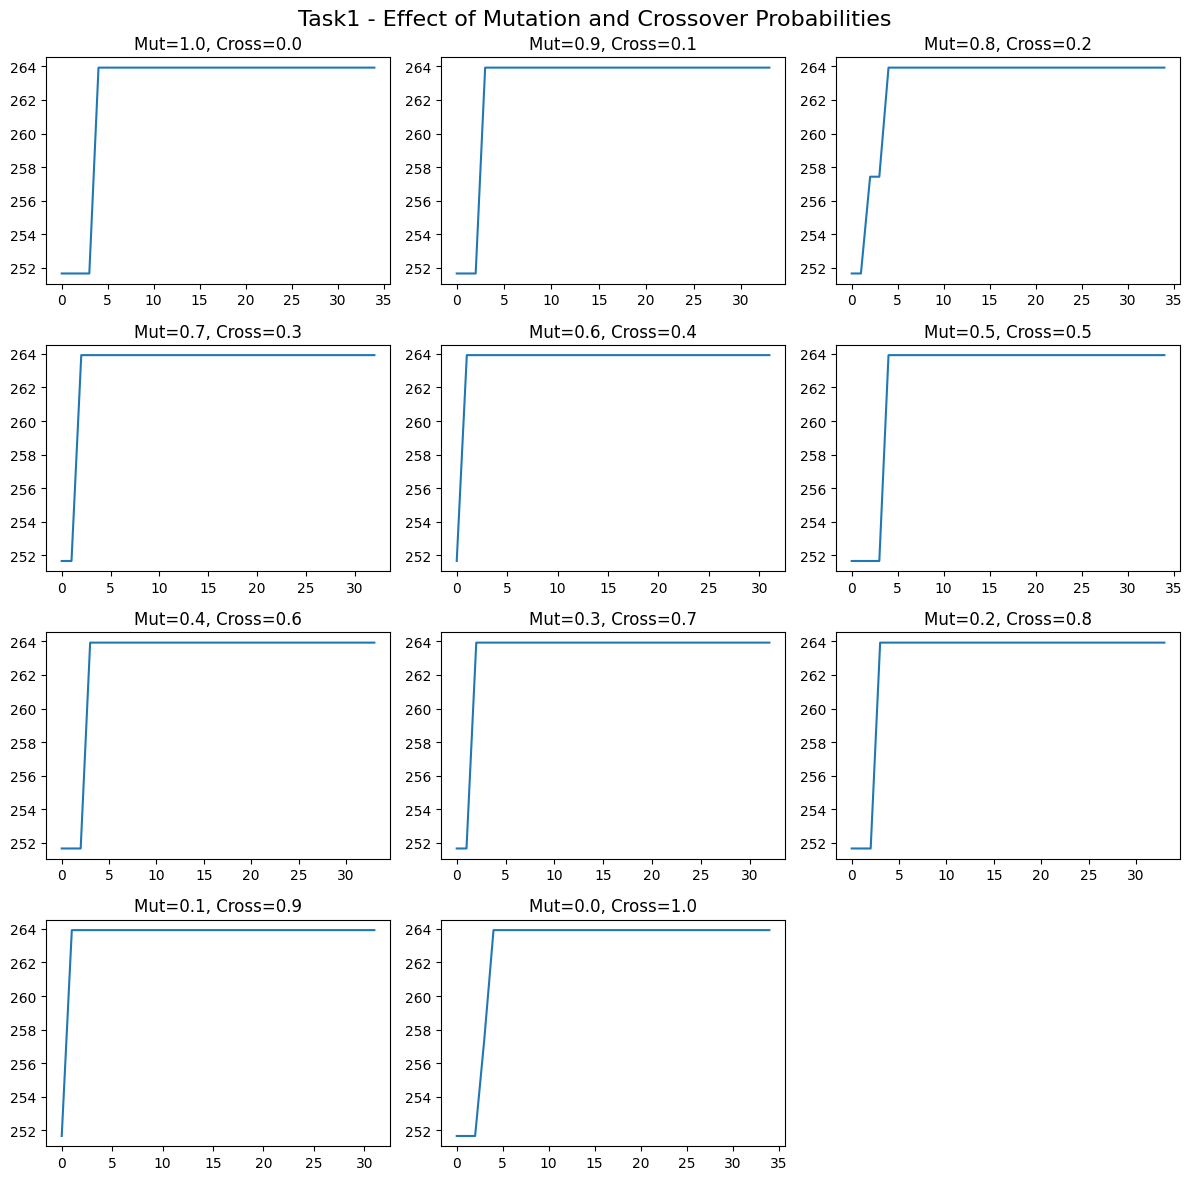

In [79]:
fig, ax = plt.subplots(4, 3, figsize=(12, 12))
ax = ax.flatten()

fig.suptitle("Task1 - Effect of Mutation and Crossover Probabilities", fontsize=16)

mut = 1
crossover = 0
for i in range(len(gas)):
    ax[i].plot(gas[i].best_solutions_fitness)
    ax[i].set_title(f"Mut={mut:.1f}, Cross={crossover:.1f}")
    mut -= 0.1
    crossover += 0.1

# Hide last empty subplot if needed
ax[-1].axis("off")

plt.tight_layout()
plt.show()


From the results we can derive that generally a higher chance of crossover with a lower chance of mutation is best. The exception being that the mutation probability shouldnt be 0.

### Task 2
When analyzing our implemenation of the second task we will again check the influence of the same parameters. We will be testing on the following graphs

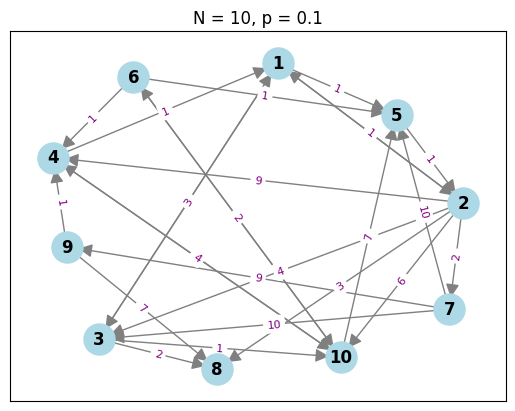

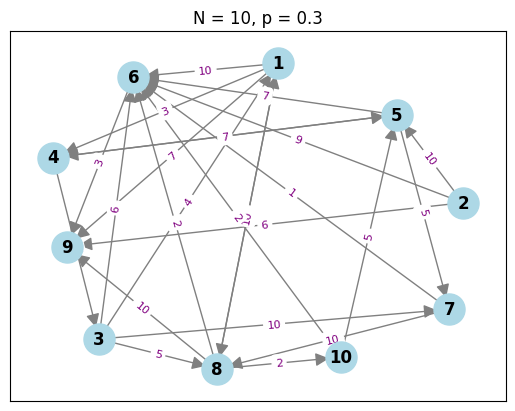

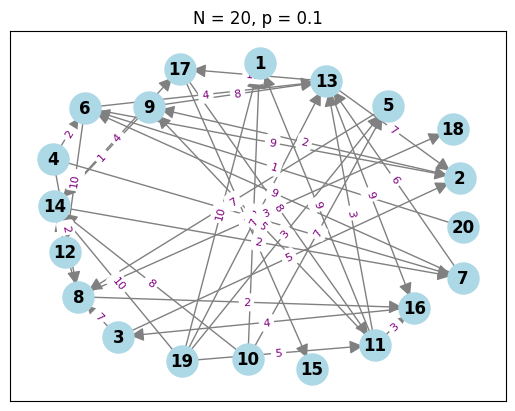

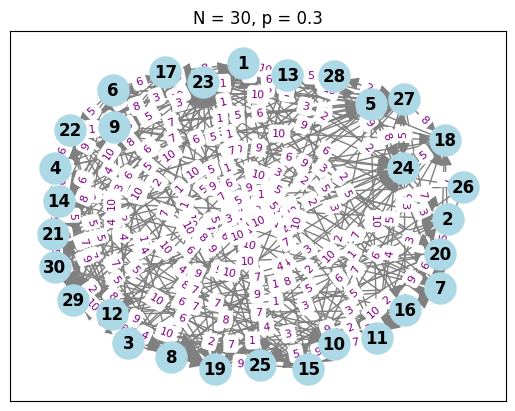

In [80]:
N, Route, adj_list, adj_matrix1 = readData('2_10_01.txt')
N, Route, adj_list, adj_matrix2 = readData('2_10_03.txt')
N, Route, adj_list, adj_matrix3 = readData('2_20_01.txt')
N, Route, adj_list, adj_matrix4 = readData('2_30_03.txt')

plot_Graph(adj_matrix1, title="N = 10, p = 0.1")
plot_Graph(adj_matrix2, title="N = 10, p = 0.3")
plot_Graph(adj_matrix3, title="N = 20, p = 0.1")
plot_Graph(adj_matrix4, title="N = 30, p = 0.3")

In [100]:
N, Route, adj_list, adj_matrix1 = readData('2_10_01.txt')
Start = Route[0]
Stop = Route[-1]
adj_matrix = adj_matrix1
path1, ga1, c1 = task2('2_10_01.txt', log_output=False)

N, Route, adj_list, adj_matrix2 = readData('2_10_03.txt')
Start = Route[0]
Stop = Route[-1]
adj_matrix = adj_matrix2
path2, ga2, c2 = task2('2_10_03.txt', log_output=False)

N, Route, adj_list, adj_matrix3 = readData('2_20_01.txt')
Start = Route[0]
Stop = Route[-1]
adj_matrix = adj_matrix3
path3, ga3, c3 = task2('2_20_01.txt', log_output=False)

N, Route, adj_list, adj_matrix4 = readData('2_30_03.txt')
Start = Route[0]
Stop = Route[-1]
adj_matrix = adj_matrix4
path4, ga4, c4 = task2('2_30_03.txt', log_output=False)

gas = [(ga1, "N = 10, p = 0.1"),(ga2, "N = 10, p = 0.3"), (ga3, "N = 20, p = 0.1"), (ga4, "N = 30, p = 0.3")]

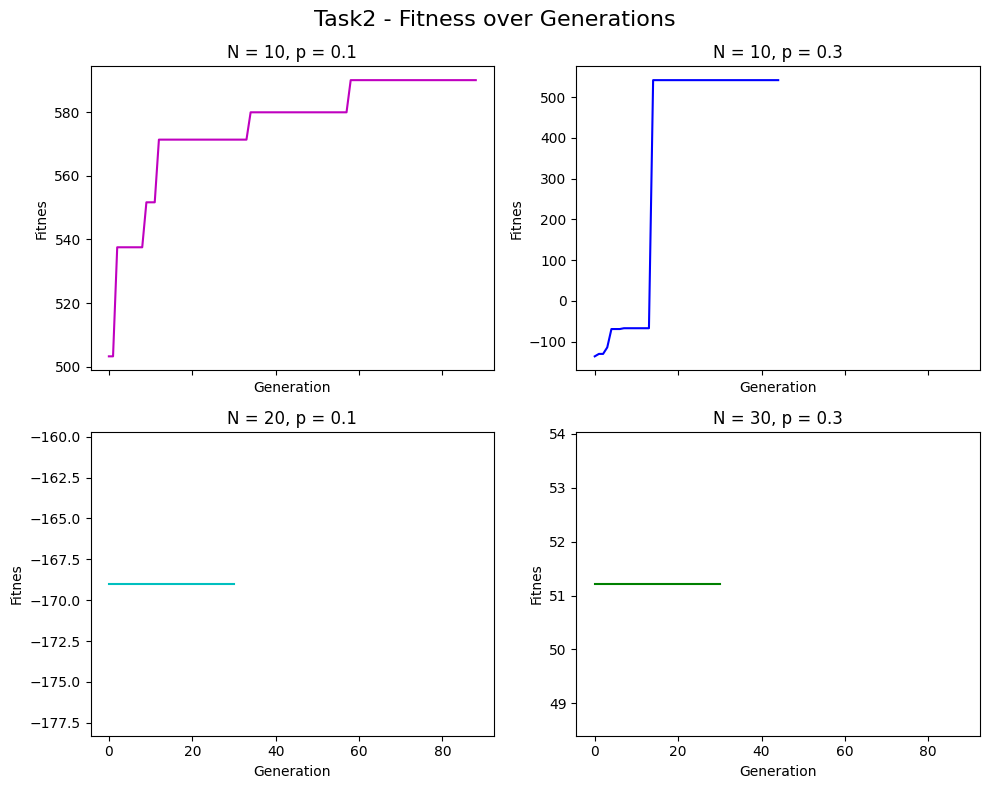

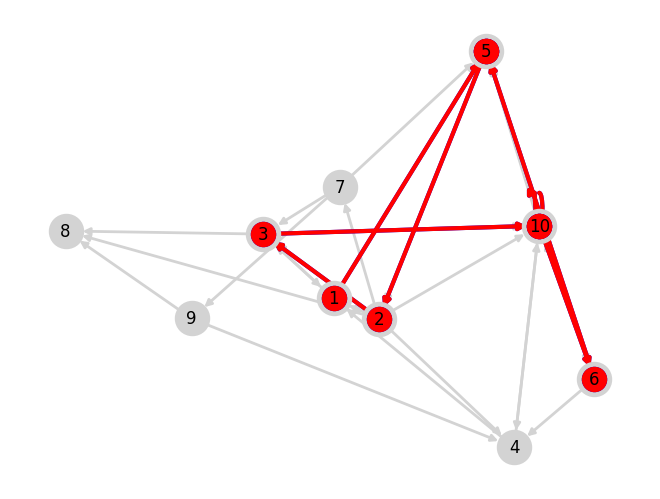

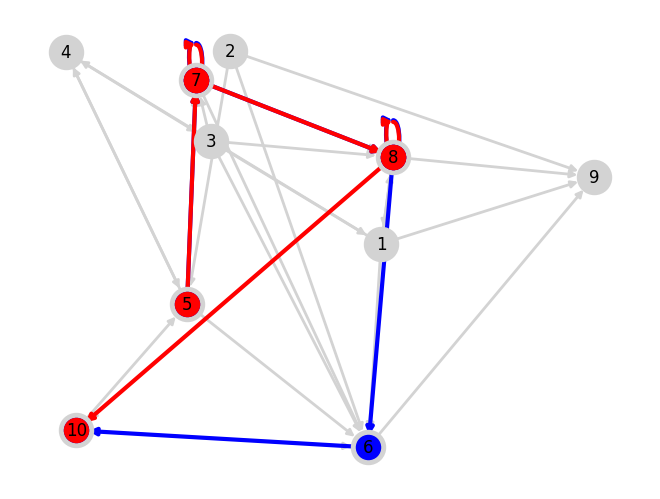

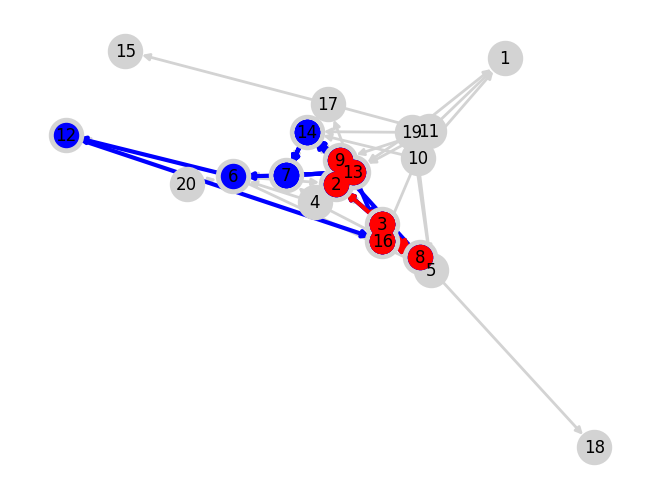

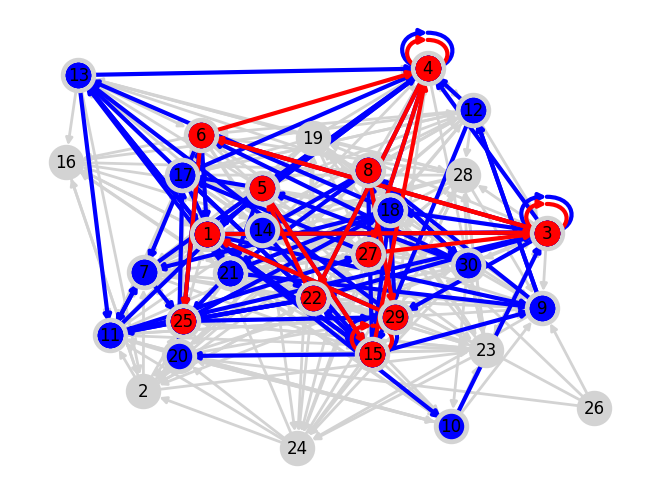

In [104]:
fig, ax = plt.subplots(2, 2, figsize=(10, 8), sharex=True)
fig.suptitle("Task2 - Fitness over Generations", fontsize=16)

ax[0][0].plot(ga1.best_solutions_fitness, color="m")
ax[0][0].set_title("N = 10, p = 0.1")
ax[0][0].set_ylabel("Fitnes")
ax[0][0].set_xlabel("Generation")

ax[0][1].plot(ga2.best_solutions_fitness, color="b")
ax[0][1].set_title("N = 10, p = 0.3")
ax[0][1].set_ylabel("Fitnes")
ax[0][1].set_xlabel("Generation")

ax[1][0].plot(ga3.best_solutions_fitness, color="c")
ax[1][0].set_title("N = 20, p = 0.1")
ax[1][0].set_ylabel("Fitnes")
ax[1][0].set_xlabel("Generation")

ax[1][1].plot(ga4.best_solutions_fitness, color="g")
ax[1][1].set_title("N = 30, p = 0.3")
ax[1][1].set_ylabel("Fitnes")
ax[1][1].set_xlabel("Generation")


plt.tight_layout()
plt.show()

how_correct2(path1, c1, 13, adj_matrix1)
how_correct2(path2, c2, 13, adj_matrix2)
how_correct2(path3, c3, 1, adj_matrix3)
how_correct2(path4, c4, 13, adj_matrix4)


We can see that again the algorithm works great on a smaller graph with many improvements, while on bigger graphs it can not find the optimal solution or even not even find a solution.

Now we will test the impact of population size and number of parents mating in the same way we did in task 1 analysis.

In [109]:
N, Route, adj_list, adj_matrix = readData('2_10_03.txt')
Start = Route[0]
Stop = Route[-1]

path1, ga1, _ = task2('2_10_03.txt', log_output=False, population_size=100, number_of_parents_mating=10)
path2, ga2, _ = task2('2_10_03.txt', log_output=False, population_size=200, number_of_parents_mating=20)
path3, ga3, _ = task2('2_10_03.txt', log_output=False, population_size=400, number_of_parents_mating=40)
path4, ga4, _ = task2('2_10_03.txt', log_output=False, population_size=800, number_of_parents_mating=80)
path5, ga5, _ = task2('2_10_03.txt', log_output=False, population_size=100, number_of_parents_mating=50)
path6, ga6, _ = task2('2_10_03.txt', log_output=False, population_size=200, number_of_parents_mating=100)
path7, ga7, _ = task2('2_10_03.txt', log_output=False, population_size=400, number_of_parents_mating=200)
path8, ga8, _ = task2('2_10_03.txt', log_output=False, population_size=800, number_of_parents_mating=400)

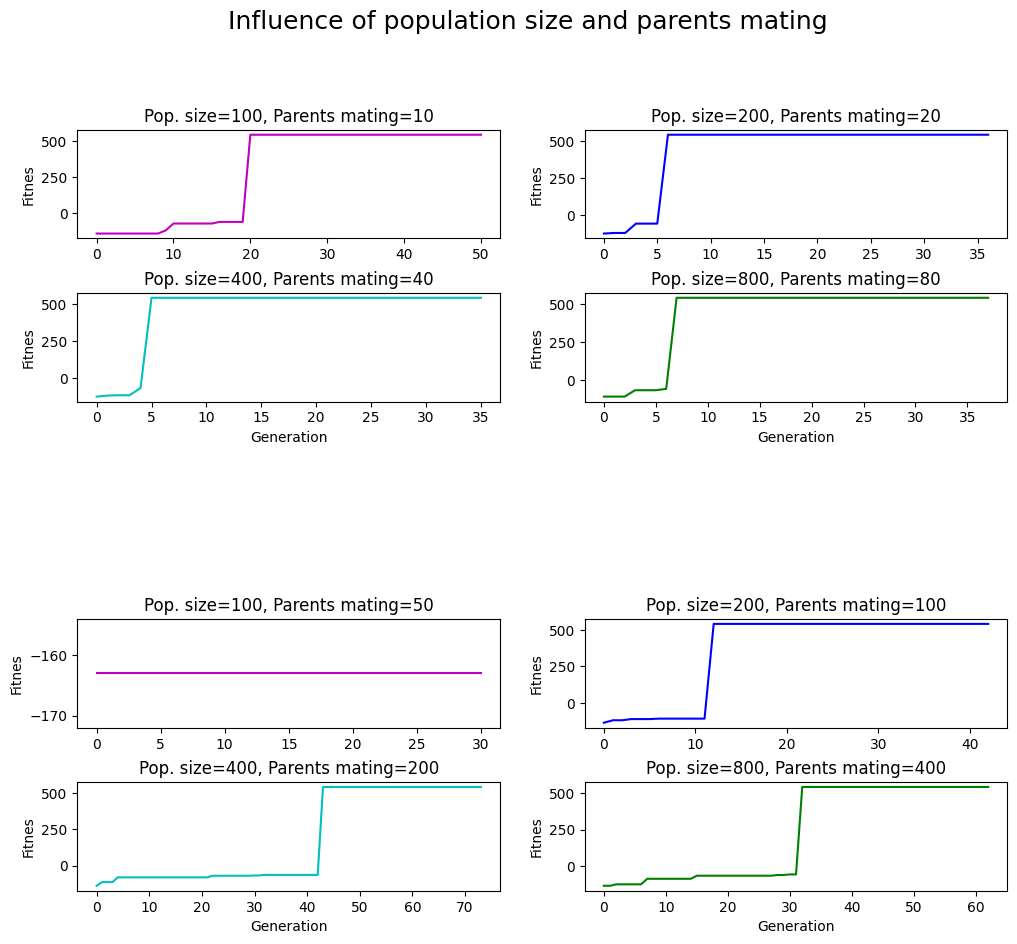

In [110]:
fig = plt.figure(figsize=(12, 12))
fig.suptitle("Influence of population size and parents mating", fontsize=18)

gs = gridspec.GridSpec(6, 2, figure=fig)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

ax5 = fig.add_subplot(gs[3, 0])
ax6 = fig.add_subplot(gs[3, 1])
ax7 = fig.add_subplot(gs[4, 0])
ax8 = fig.add_subplot(gs[4, 1])

plt.subplots_adjust(hspace=0.5)

ax1.plot(ga1.best_solutions_fitness, color="m")
ax1.set_title("Pop. size=100, Parents mating=10")
ax1.set_ylabel("Fitnes")

ax2.plot(ga2.best_solutions_fitness, color="b")
ax2.set_title("Pop. size=200, Parents mating=20")
ax2.set_ylabel("Fitnes")

ax3.plot(ga3.best_solutions_fitness, color="c")
ax3.set_title("Pop. size=400, Parents mating=40")
ax3.set_ylabel("Fitnes")
ax3.set_xlabel("Generation")

ax4.plot(ga4.best_solutions_fitness, color="g")
ax4.set_title("Pop. size=800, Parents mating=80")
ax4.set_ylabel("Fitnes")
ax4.set_xlabel("Generation")

ax5.plot(ga5.best_solutions_fitness, color="m")
ax5.set_title("Pop. size=100, Parents mating=50")
ax5.set_ylabel("Fitnes")

ax6.plot(ga6.best_solutions_fitness, color="b")
ax6.set_title("Pop. size=200, Parents mating=100")
ax6.set_ylabel("Fitnes")

ax7.plot(ga7.best_solutions_fitness, color="c")
ax7.set_title("Pop. size=400, Parents mating=200")
ax7.set_ylabel("Fitnes")
ax7.set_xlabel("Generation")

ax8.plot(ga8.best_solutions_fitness, color="g")
ax8.set_title("Pop. size=800, Parents mating=400")
ax8.set_ylabel("Fitnes")
ax8.set_xlabel("Generation")

plt.show()

We can observe that the result is similar to task 1 analysis, where having the number of parents mating be 10% of the total population is better.

Next we will test how changing the probability of mutation and crossover affects task 2.

In [113]:
N, Route, adj_list, adj_matrix = readData('2_10_03.txt')
Start = Route[0]
Stop = Route[-1]
num_path = len(Route)
num_nodes = N

initial_pop = []
for i in range(500):
    gene = []
    for j in range(num_path-1):
        start, stop = Route[j], Route[j+1]
        gene.extend(random_gene2(num_nodes, 0.3,start,stop))
    initial_pop.append(gene)

path1, ga1, c1 = task2('2_10_03.txt', log_output=False, mutation_probability=1, crossover_probability=0, initial_pop=initial_pop)
path2, ga2, c2 = task2('2_10_03.txt', log_output=False, mutation_probability=0.9, crossover_probability=0.1, initial_pop=initial_pop)
path3, ga3, c3 = task2('2_10_03.txt', log_output=False, mutation_probability=0.8, crossover_probability=0.2, initial_pop=initial_pop)
path4, ga4, _ = task2('2_10_03.txt', log_output=False, mutation_probability=0.7, crossover_probability=0.3, initial_pop=initial_pop)
path5, ga5, _ = task2('2_10_03.txt', log_output=False, mutation_probability=0.6, crossover_probability=0.4, initial_pop=initial_pop)
path6, ga6, _ = task2('2_10_03.txt', log_output=False, mutation_probability=0.5, crossover_probability=0.5, initial_pop=initial_pop)
path7, ga7, _ = task2('2_10_03.txt', log_output=False, mutation_probability=0.4, crossover_probability=0.6, initial_pop=initial_pop)
path8, ga8, _ = task2('2_10_03.txt', log_output=False, mutation_probability=0.3, crossover_probability=0.7, initial_pop=initial_pop)
path9, ga9, _ = task2('2_10_03.txt', log_output=False, mutation_probability=0.2, crossover_probability=0.8, initial_pop=initial_pop)
path10, ga10, _ = task2('2_10_03.txt', log_output=False, mutation_probability=0.1, crossover_probability=0.9, initial_pop=initial_pop)
path11, ga11, _ = task2('2_10_03.txt', log_output=False, mutation_probability=0, crossover_probability=1, initial_pop=initial_pop)
gas = [ga1,ga2,ga3,ga4,ga5,ga6,ga7,ga8,ga9,ga10,ga11]

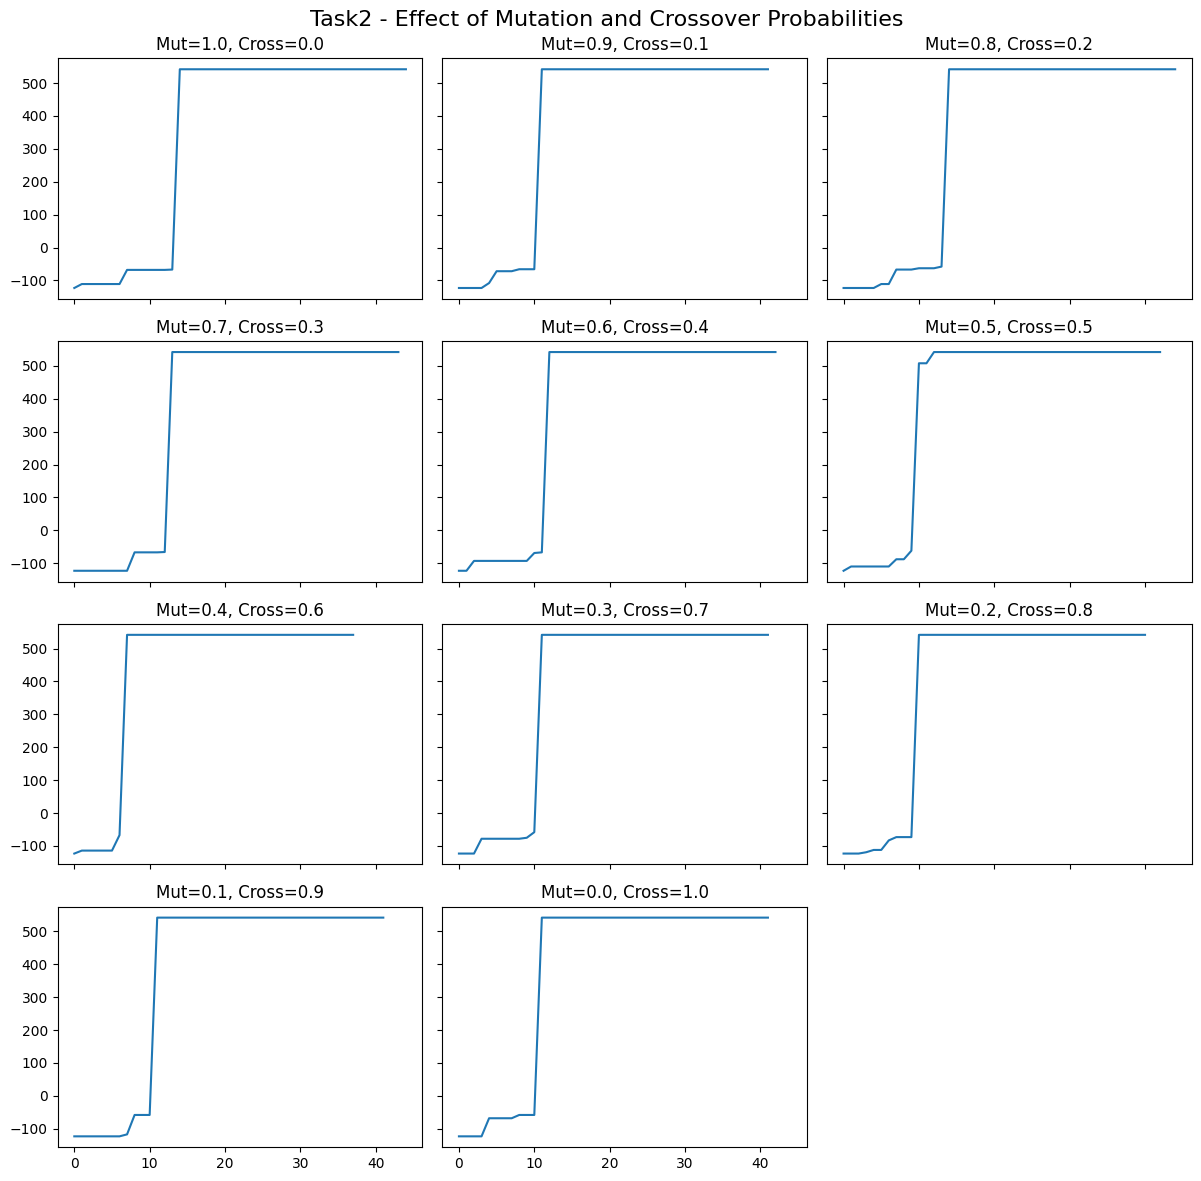

In [117]:
fig, ax = plt.subplots(4, 3, figsize=(12, 12), sharex=True, sharey=True)
ax = ax.flatten()

fig.suptitle("Task2 - Effect of Mutation and Crossover Probabilities", fontsize=16)

mut = 1
crossover = 0
for i in range(len(gas)):
    ax[i].plot(gas[i].best_solutions_fitness)
    ax[i].set_title(f"Mut={mut:.1f}, Cross={crossover:.1f}")
    mut -= 0.1
    crossover += 0.1

# Hide last empty subplot if needed
ax[-1].axis("off")

plt.tight_layout()
plt.show()


The results are again similar to the first task, where having a smaller mutation probability with a higher crossover probability is better.

#### Task 3
We will be testing on the following graphs.

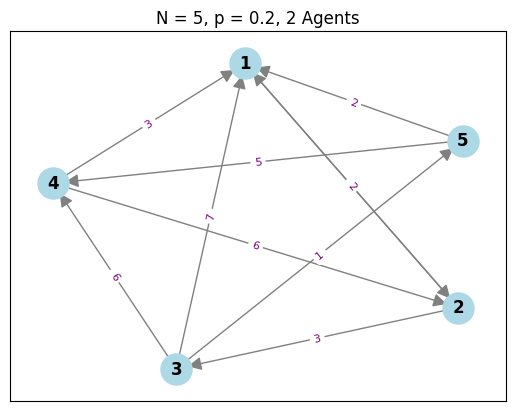

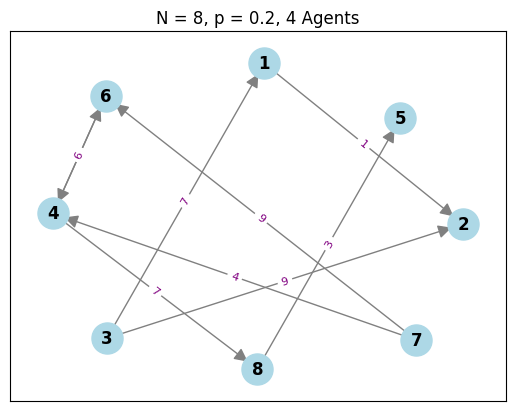

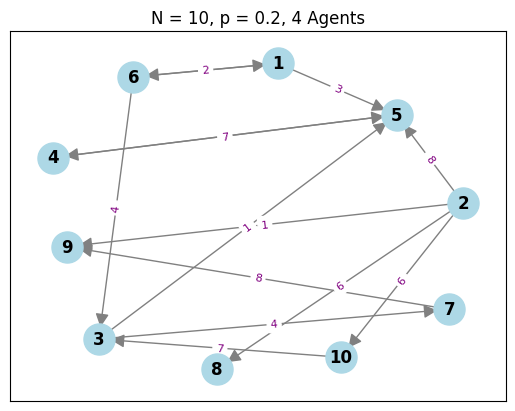

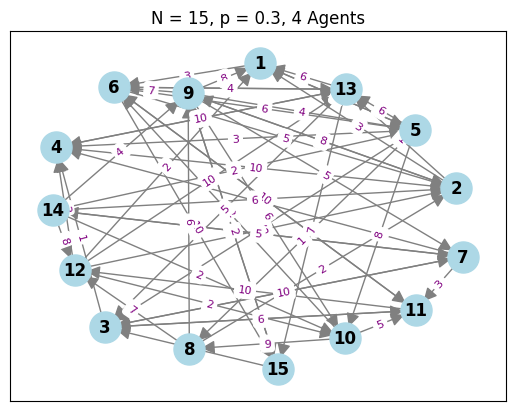

In [139]:
N, Route, Agents, adj_list, adj_matrix1 = readData3('3_5_02_2.txt')
N, Route, Agents, adj_list, adj_matrix2 = readData3('3_8_02_4.txt')
N, Route, Agents, adj_list, adj_matrix3 = readData3('3_10_02_4.txt')
N, Route, Agents, adj_list, adj_matrix4 = readData3('3_15_03_4.txt')

plot_Graph(adj_matrix1, title="N = 5, p = 0.2, 2 Agents")
plot_Graph(adj_matrix2, title="N = 8, p = 0.2, 2 Agents")
plot_Graph(adj_matrix3, title="N = 10, p = 0.2, 4 Agents")
plot_Graph(adj_matrix4, title="N = 15, p = 0.3, 4 Agents")

First we will test the effectivness of our implementation on varying graph sizes.

In [144]:
N, Route, Agents, adj_list, adj_matrix = readData3('3_5_02_2.txt')
Start = Route[0]
Stop = Route[-1]
path, ga1, _ = task3('3_5_02_2.txt', log_output=True)

N, Route, Agents, adj_list, adj_matrix = readData3('3_8_02_4.txt')
Start = Route[0]
Stop = Route[-1]
path, ga2, _ = task3('3_8_02_4.txt', log_output=True)

N, Route, Agents, adj_list, adj_matrix = readData3('3_10_02_4.txt')
Start = Route[0]
Stop = Route[-1]
path, ga3, _ = task3('3_10_02_4.txt', log_output=True)

N, Route, Agents, adj_list, adj_matrix = readData3('3_15_03_4.txt')
Start = Route[0]
Stop = Route[-1]
path, ga4, _ = task3('3_15_03_4.txt', log_output=True)

Generation 1: Best fitness = 86.00, Path length: 15 with cost 16, Population diversity: 0.859
Generation 2: Best fitness = 86.00, Path length: 16 with cost 16, Population diversity: 0.936
Generation 3: Best fitness = 94.00, Path length: 16 with cost 8, Population diversity: 0.961
Generation 4: Best fitness = 94.00, Path length: 15 with cost 6, Population diversity: 0.979
Generation 5: Best fitness = 132.00, Path length: 19 with cost 20, Population diversity: 0.975
Generation 6: Best fitness = 132.00, Path length: 19 with cost 20, Population diversity: 0.983
Generation 7: Best fitness = 132.00, Path length: 19 with cost 20, Population diversity: 0.984
Generation 8: Best fitness = 132.00, Path length: 19 with cost 20, Population diversity: 0.989
Generation 9: Best fitness = 132.00, Path length: 19 with cost 20, Population diversity: 0.990
Generation 10: Best fitness = 132.00, Path length: 19 with cost 20, Population diversity: 0.992
Generation 11: Best fitness = 132.00, Path length: 19 w

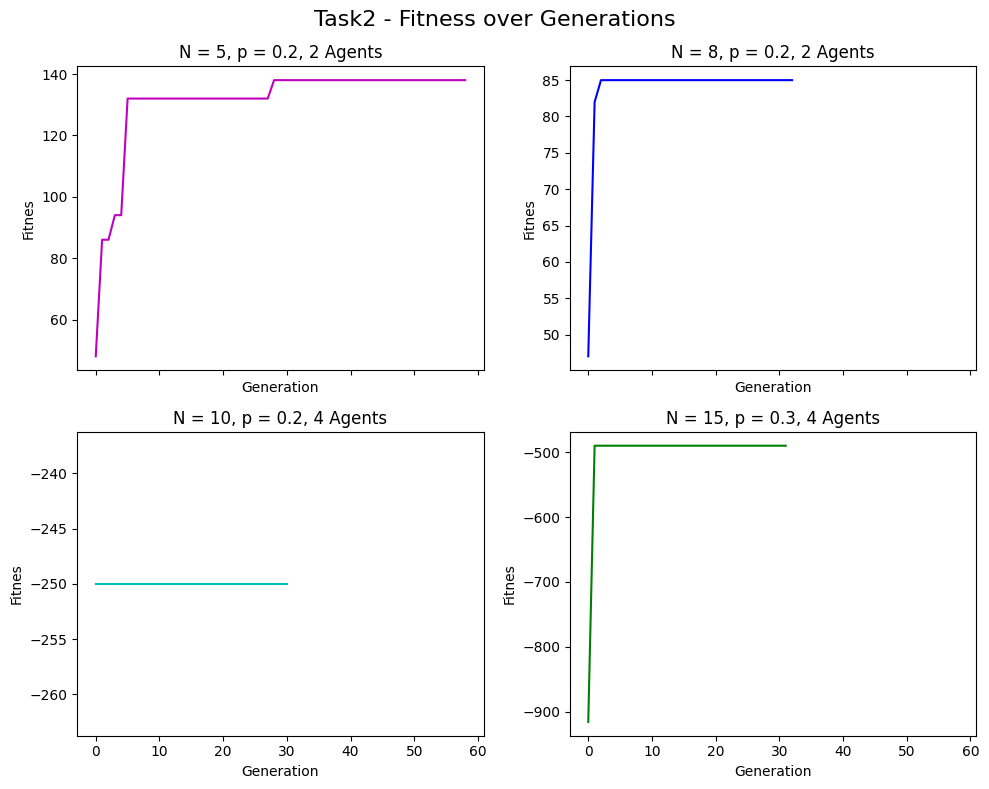

In [145]:
fig, ax = plt.subplots(2, 2, figsize=(10, 8), sharex=True)
fig.suptitle("Task2 - Fitness over Generations", fontsize=16)

ax[0][0].plot(ga1.best_solutions_fitness, color="m")
ax[0][0].set_title("N = 5, p = 0.2, 2 Agents")
ax[0][0].set_ylabel("Fitnes")
ax[0][0].set_xlabel("Generation")

ax[0][1].plot(ga2.best_solutions_fitness, color="b")
ax[0][1].set_title("N = 8, p = 0.2, 2 Agents")
ax[0][1].set_ylabel("Fitnes")
ax[0][1].set_xlabel("Generation")

ax[1][0].plot(ga3.best_solutions_fitness, color="c")
ax[1][0].set_title("N = 10, p = 0.2, 4 Agents")
ax[1][0].set_ylabel("Fitnes")
ax[1][0].set_xlabel("Generation")

ax[1][1].plot(ga4.best_solutions_fitness, color="g")
ax[1][1].set_title("N = 15, p = 0.3, 4 Agents")
ax[1][1].set_ylabel("Fitnes")
ax[1][1].set_xlabel("Generation")


plt.tight_layout()
plt.show()

From the results we can see that the algorithm struggles to find the soulution, even on smaller graphs and on the bigger ones it's stuck either on the initial solution or a wrong one.

Moving forward we will be using the smallest graph to save on computation time and as the algorithm works best on it. The smalles graph has 5 nodes with 2 agents and a route of length 3.
We will begin by testing the effect of population size on the solution.


In [146]:
N, Route, Agents, adj_list, adj_matrix = readData3('3_5_02_2.txt')
Start = Route[0]
Stop = Route[-1]

path1, ga1, _ = task3('3_5_02_2.txt', log_output=False, population_size=400, number_of_parents_mating=40)
path2, ga2, _ = task3('3_5_02_2.txt', log_output=False, population_size=800, number_of_parents_mating=80)
path3, ga3, _ = task3('3_5_02_2.txt', log_output=False, population_size=400, number_of_parents_mating=200)
path4, ga4, _ = task3('3_5_02_2.txt', log_output=False, population_size=800, number_of_parents_mating=400)

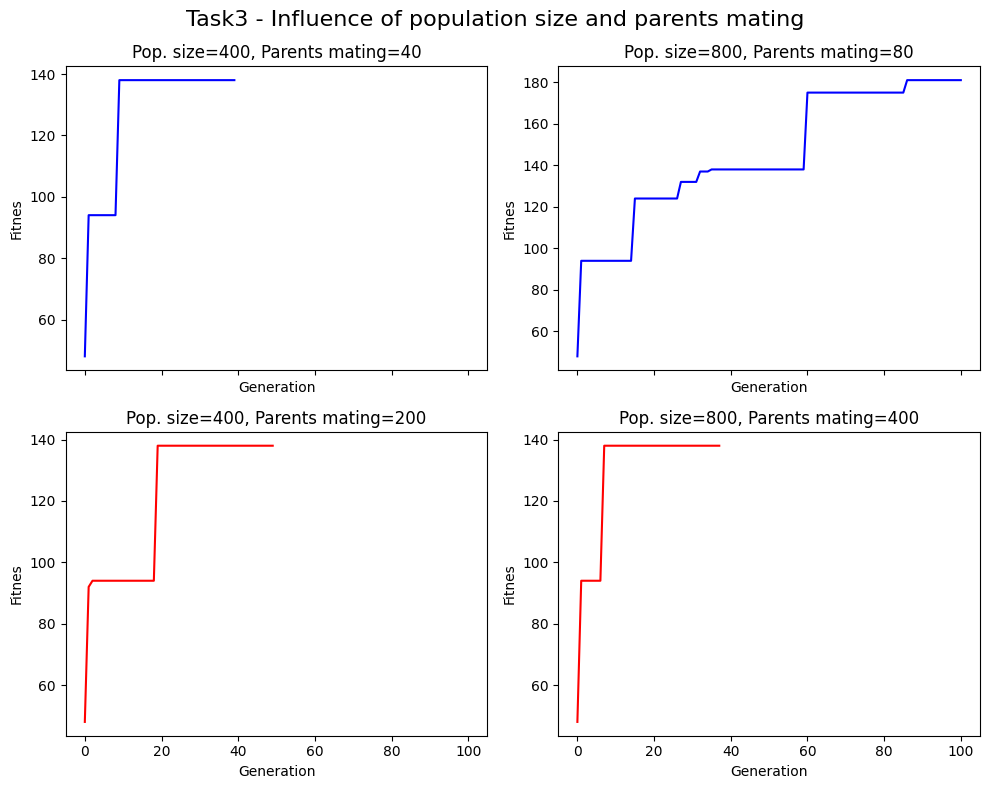

In [147]:
fig, ax = plt.subplots(2, 2, figsize=(10, 8), sharex=True)
fig.suptitle("Task3 - Influence of population size and parents mating", fontsize=16)

ax[0][0].plot(ga1.best_solutions_fitness, color="b")
ax[0][0].set_title("Pop. size=400, Parents mating=40")
ax[0][0].set_ylabel("Fitnes")
ax[0][0].set_xlabel("Generation")

ax[0][1].plot(ga2.best_solutions_fitness, color="b")
ax[0][1].set_title("Pop. size=800, Parents mating=80")
ax[0][1].set_ylabel("Fitnes")
ax[0][1].set_xlabel("Generation")

ax[1][0].plot(ga3.best_solutions_fitness, color="r")
ax[1][0].set_title("Pop. size=400, Parents mating=200")
ax[1][0].set_ylabel("Fitnes")
ax[1][0].set_xlabel("Generation")

ax[1][1].plot(ga4.best_solutions_fitness, color="r")
ax[1][1].set_title("Pop. size=800, Parents mating=400")
ax[1][1].set_ylabel("Fitnes")
ax[1][1].set_xlabel("Generation")


plt.tight_layout()
plt.show()

From the results we can see that a bigger population size helps in finding a better solution and we also see the same result as in task 1 and task 2 where having the number of parents mating be 10% improves the algorithm.

And finally we will test the effect of mutation and crossover probability on the algorithm. Here we will be using a population size of 1000 and all the ga's will start with the same population.

In [151]:
N, Route, Agents, adj_list, adj_matrix = readData3('3_5_02_2.txt')
Start = Route[0]
Stop = Route[-1]

num_nodes = adj_matrix.shape[0]
num_path = len(Route)
num_agents = len(Agents)

pop_size = 1000
initial_pop = []
for i in range(pop_size):
    gene = []
    for k in Agents:
        agent = []
        agent.extend(random_gene3(num_nodes, 0.3,k,Route[0]))
        for j in range(num_path - 1):
            start, stop = Route[j], Route[j+1]
            agent.extend(random_gene3(num_nodes, 0.3,start,stop))
        gene.extend(agent)
    initial_pop.append(gene)

path1, ga1, c1 = task3('3_5_02_2.txt', log_output=False, mutation_probability=1, crossover_probability=0, initial_pop=initial_pop)
path2, ga2, c3 = task3('3_5_02_2.txt', log_output=False, mutation_probability=0.8, crossover_probability=0.2, initial_pop=initial_pop)
path3, ga3, _ = task3('3_5_02_2.txt', log_output=False, mutation_probability=0.6, crossover_probability=0.4, initial_pop=initial_pop)
path4, ga4, _ = task3('3_5_02_2.txt', log_output=False, mutation_probability=0.4, crossover_probability=0.6, initial_pop=initial_pop)
path5, ga5, _ = task3('3_5_02_2.txt', log_output=False, mutation_probability=0.2, crossover_probability=0.8, initial_pop=initial_pop)
path6, ga6, _ = task3('3_5_02_2.txt', log_output=False, mutation_probability=0, crossover_probability=1, initial_pop=initial_pop)
gas = [ga1,ga2,ga3,ga4,ga5,ga6]

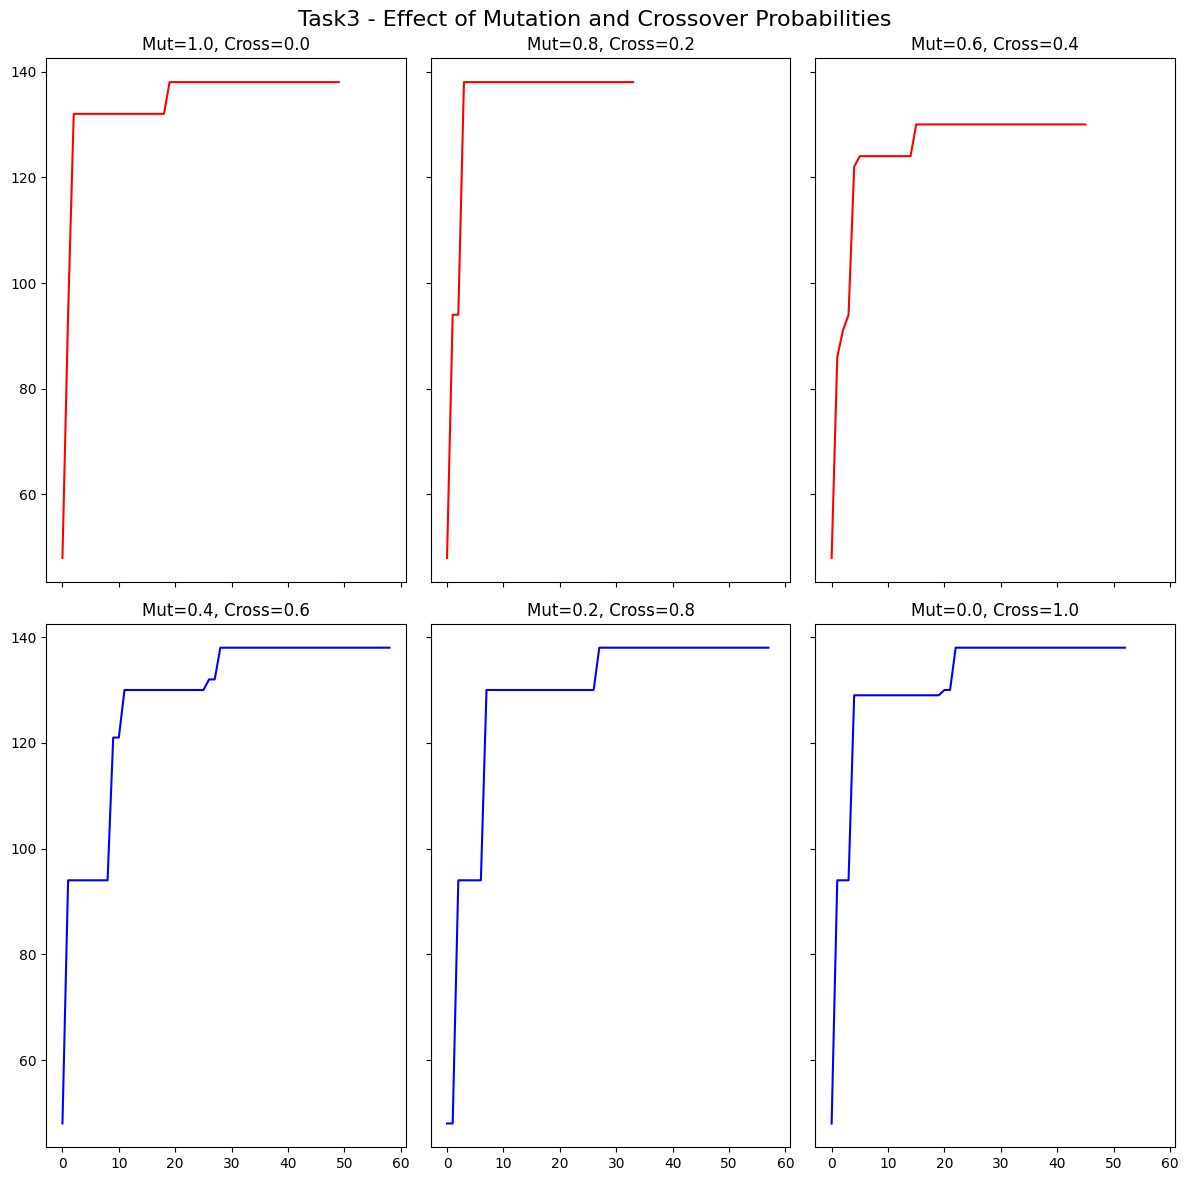

In [154]:
fig, ax = plt.subplots(2, 3, figsize=(12, 12), sharex=True, sharey=True)
ax = ax.flatten()

fig.suptitle("Task3 - Effect of Mutation and Crossover Probabilities", fontsize=16)

mut = 1
crossover = 0
for i in range(len(gas)):
    color="b"
    if i < 3:
        color="r"
    ax[i].plot(gas[i].best_solutions_fitness, color=color)
    ax[i].set_title(f"Mut={mut:.1f}, Cross={crossover:.1f}")
    mut -= 0.2
    crossover += 0.2

plt.tight_layout()
plt.show()

We can observe that again the algorithm seems better with a higher chance of crossover and a lower chance of mutation.

At the end lets also check if the solution the algorithm gave us is even valid. To do that lets run the output through the fitnes function again while saving the amount of incorrect edges and incorrect intervals

In [155]:
def fitnes3_check(solution):
    num_nodes = adj_matrix.shape[0]
    num_path = len(Route)
    num_agents = len(Agents)

    edge_penalty = 50
    interval_penalty = 100
    result = 0
    invalid_edges = 0
    intervals = {}

    # Process each agent
    for agent_idx in range(num_agents + 1):
        offset = (num_path-1) * num_nodes * agent_idx
        # Process each segment of agent
        time = 0
        last = 0
        if agent_idx == num_agents:
            last = 1
        for segment_idx in range(num_path - 1 + last):
            start_pos = segment_idx * num_nodes + offset
            end_pos = start_pos + num_nodes
            segment = solution[start_pos:end_pos]

            path_nodes = [node for node in segment if node != -1]

            previous_node = -2
            wait_count = 0

            # Calculate distances for consecutive nodes
            for i in range(len(path_nodes) - 1):
                first = path_nodes[i] - 1  # Convert to 0-indexed
                second = path_nodes[i + 1] - 1

                if first != -3 and second != -3:
                    # First and second arent wait
                    distance = adj_matrix.iloc[first, second]
                    if distance == -1:
                        invalid_edges += 1
                    else:
                        # Base wait is 10 time units
                        if not intervals.get(first):
                            intervals[first] = []
                        intervals[first].append((int(time), int(time + 10)))
                        time += 10 + distance
                        result += distance

                elif first != -3 and second == -3:
                    # First is node, Second is wait so start counting chain
                    previous_node = first
                    wait_count += 1

                elif first == -3 and second == -3:
                    # First and Second are wait so count up
                    wait_count += 1

                else:
                    # First is wait, Second is node stop chain and calculate interval
                    distance = adj_matrix.iloc[previous_node, second]
                    if distance == -1:
                        invalid_edges += 1
                    else:
                        # Base wait is 10 time units + 20 per wait in chain
                        if not intervals.get(previous_node):
                            intervals[previous_node] = []
                        intervals[previous_node].append((int(time), int(time + 10 + 20 * wait_count)))
                        time += 10 + 20 * wait_count + distance
                        result += distance
                    previous_node = -2
                    wait_count = 0

    # Count invalid intervals
    invalid_intervals = 0
    for node, node_intervals in intervals.items():
        events = []
        for start, end in node_intervals:
            events.append((start, 1))   # interval starts
            events.append((end, -1))    # interval ends
        events.sort()

        active = 0
        for time, event_type in events:
            if event_type == 1:
                # new interval starts
                if active > 0:
                    invalid_intervals += 1
                active += 1
            else:
                active -= 1


    fitness = -result
    fitness -= invalid_edges * edge_penalty
    fitness -= invalid_intervals * interval_penalty

    if invalid_edges == 0 and invalid_intervals == 0:
        fitness += 500
        fitness += 1000/result
    elif invalid_intervals == 0:
        fitness += 300
    elif invalid_edges == 0:
        fitness += 150

    return invalid_edges, invalid_intervals

In [159]:
fitnes3_check(ga4.best_solution()[0])

(3, 0)

We can see that while the algorithm has correctly accounted for the intervals, it hasn't done so for the edges. It is possible that running the genetic algorithm longer with a higher population count would make it find a valid solution.